In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from typing import Callable, Optional, Tuple, Dict
import ipywidgets as widgets
from IPython.display import display
import ipympl

import os
import glob
import warnings
from scipy.interpolate import RectBivariateSpline, RegularGridInterpolator


# # Plot formatting
# plt.rcParams['figure.figsize'] = (8, 5)
# plt.rcParams['font.size'] = 11
# plt.rcParams['axes.grid'] = True

In [21]:
@dataclass
class RotorGeometry:
    radius: float                         # Rotor radius R [m]
    root_cutout: float                    # Root cutout radius R_rc [m]
    num_blades: int                       # Number of blades b [-]
    chord_func: Callable[[float], float]  # Local chord distribution c(r) [m]
    twist_func: Callable[[float], float]  # Local pitch distribution theta(r) [rad]

@dataclass
class FlightCondition:
    v_axial: float                        # Axial/climb/cruise velocity V [m/s]
    rpm: float                            # Rotational speed [RPM]
    rho: float = 1.225                    # Air density [kg/m^3]
    speed_of_sound: float = 340.29        # Speed of sound a_inf [m/s]

    @property
    def omega(self) -> float:
        return self.rpm * (2.0 * np.pi / 60.0)

@dataclass
class BEMTResult:
    thrust: float
    torque: float
    power: float
    ct: float
    cq: float
    cp: float
    solidity: float
    figure_of_merit: float
    propulsive_eff: float
    stall_fraction: float
    tip_mach: float
    
    r_stations: np.ndarray
    dr: np.ndarray
    inflow_ratio: np.ndarray
    lambda_i: np.ndarray
    lambda_c: float
    phi: np.ndarray             
    alpha: np.ndarray
    cl: np.ndarray
    cd: np.ndarray
    d_thrust: np.ndarray
    d_torque: np.ndarray
    d_power: np.ndarray
    stalled_mask: np.ndarray

class AirfoilModel:
    def __init__(
        self,
        airfoil_name: str = "NACA 0012",
        search_dirs=("airfoils", "."),
        cl_slope_fallback: float = 5.75,
        cd0_fallback: float = 0.0113,
        cd2_fallback: float = 1.25,
        alpha_stall_deg_fallback: float = 14.0,
        ncrit_pref: Optional[int] = 9,
        use_analytical: bool = False
    ):
        self.airfoil_name = airfoil_name
        self.search_dirs = search_dirs
        self.cl_slope_fallback = cl_slope_fallback
        self.cd0_fallback = cd0_fallback
        self.cd2_fallback = cd2_fallback
        self.alpha_stall = np.radians(alpha_stall_deg_fallback)
        self.use_analytical = use_analytical or (airfoil_name == "Knight & Hefner (1937)")
        self.has_polars = False
        self.re_list = []
        self.raw_data = {}
        
        if not self.use_analytical:
            ensure_airfoil_data(self.airfoil_name)
            self._build_polar_interpolators(ncrit_pref)

In [33]:
%matplotlib widget
import os
import glob
import urllib.request
import pandas as pd
import numpy as np
from typing import Tuple, Optional, List
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --- 1. Master Airfoil Catalog with Canonical Names ---
MASTER_CATALOG = [
    # Selig (High-lift / low-Re UAV & Rotorcraft)
    'S1210', 'S1223', 'S1223 RTL', 'S8035', 'S8036', 'S8037', 'S8052', 'S9000',
    'SD7003', 'SD7032', 'SD7037', 'SD7062', 'SD7080', 'SD8000',
    # NACA 4, 5, 6-digit Series
    'NACA 0006', 'NACA 0009', 'NACA 0012', 'NACA 0015', 'NACA 0018', 'NACA 0021', 'NACA 0024',
    'NACA 1408', 'NACA 1410', 'NACA 1412', 'NACA 2412', 'NACA 2415', 'NACA 2418', 'NACA 2421', 'NACA 2424',
    'NACA 4412', 'NACA 4415', 'NACA 4418', 'NACA 4421', 'NACA 4424',
    'NACA 23012', 'NACA 23015', 'NACA 23018', 'NACA 23021', 'NACA 23024',
    'NACA 63-212', 'NACA 63-412', 'NACA 64-212', 'NACA 64-415',
    # Eppler Series
    'E193', 'E205', 'E214', 'E387', 'E420', 'E423', 'E560',
    # MH / RG / Pylon Series
    'MH 32', 'MH 45', 'MH 60', 'MH 114', 'MH 115', 'MH 120', 'RG 15',
    # General Aviation & Classic
    'Clark Y', 'Clark YH', 'Gottingen 398', 'Gottingen 535', 'USA 35B', 'FX 63-137', 'FX 74-CL5-140'
]

def to_airfoiltools_slug(name: str) -> str:
    """Accurately maps display names to Airfoil Tools database identifiers."""
    clean = name.lower().strip().replace(" ", "").replace("-", "").replace("_", "")
    
    known_mappings = {
        'clarky': 'clarky-il',
        'clarkyh': 'clarkyh-il',
        'gottingen398': 'goe398-il',
        'gottingen535': 'goe535-il',
        'goe398': 'goe398-il',
        'goe535': 'goe535-il',
        'usa35b': 'usa35b-il',
        's1223rtl': 's1223rtl-il',
        'fx63137': 'fx63137-il',
        'fx74cl5140': 'fx74cl5140-il',
    }
    if clean in known_mappings:
        return known_mappings[clean]
        
    if clean.startswith("naca"):
        digits = clean.replace("naca", "")
        return f"n{digits}-il"
    
    if clean.endswith("il") or clean.endswith("sa"):
        return clean
    return f"{clean}-il"

def normalize_name(name: str) -> str:
    return to_airfoiltools_slug(name).replace("-il", "").replace("-sa", "")

def get_all_available_airfoils() -> List[str]:
    """Deduplicates discovered files against master catalog."""
    found_files = glob.glob("*.csv") + glob.glob("*.txt") + glob.glob("airfoils/*.csv") + glob.glob("airfoils/*/*.csv")
    disk_airfoils = set()
    
    rev_map = {
        'n0012': 'NACA 0012', 'n0015': 'NACA 0015',
        'clarky': 'Clark Y', 'clarkyh': 'Clark YH',
        'goe398': 'Gottingen 398', 'goe535': 'Gottingen 535',
        's1223': 'S1223', 's1210': 'S1210', 'e423': 'E423'
    }
    
    for f in found_files:
        fname = os.path.basename(f).lower()
        if fname.startswith("xf-"):
            p = fname.split("-")
            if len(p) >= 3:
                code = p[1].lower()
                disp_name = rev_map.get(code, p[1].upper())
                disk_airfoils.add(disp_name)

    seen_slugs = set()
    deduped_list = []
    for item in (MASTER_CATALOG + list(disk_airfoils)):
        slug = to_airfoiltools_slug(item)
        if slug not in seen_slugs:
            seen_slugs.add(slug)
            deduped_list.append(item)

    return sorted(deduped_list)

def filter_airfoil_catalog(query: str, catalog: List[str]) -> List[str]:
    q = query.lower().replace(" ", "").replace("-", "")
    if not q:
        return catalog
    prefix = [af for af in catalog if af.lower().replace(" ", "").replace("-", "").startswith(q)]
    subs = [af for af in catalog if q in af.lower().replace(" ", "").replace("-", "") and af not in prefix]
    return prefix + subs


# --- 2. Online Fetcher & Local Cache ---
def ensure_airfoil_data(airfoil_name: str, airfoil_dir: str = "airfoils"):
    os.makedirs(airfoil_dir, exist_ok=True)
    slug = to_airfoiltools_slug(airfoil_name)
    target_dir = os.path.join(airfoil_dir, slug)
    os.makedirs(target_dir, exist_ok=True)

    # 1. Fetch Coordinates (.dat)
    dat_path = os.path.join(target_dir, f"{slug}.dat")
    if not os.path.exists(dat_path):
        try:
            url_dat = f"http://airfoiltools.com/airfoil/seligdatfile?airfoil={slug}"
            req = urllib.request.Request(url_dat, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=3) as resp:
                content = resp.read().decode('utf-8')
                if len(content) > 100 and "<html>" not in content.lower():
                    with open(dat_path, 'w') as f:
                        f.write(content)
        except Exception:
            pass

    # 2. Fetch Polars across standard Re spectrum
    re_list = [50000, 100000, 200000, 500000, 1000000]
    for re_v in re_list:
        for nc_str, nc_tag in [("", ""), ("-n5", "-n5")]:
            csv_path = os.path.join(target_dir, f"xf-{slug}-{re_v}{nc_tag}.csv")
            if not os.path.exists(csv_path):
                try:
                    url_csv = f"http://airfoiltools.com/polar/csv?polar=xf-{slug}-{re_v}{nc_str}"
                    req = urllib.request.Request(url_csv, headers={'User-Agent': 'Mozilla/5.0'})
                    with urllib.request.urlopen(req, timeout=3) as resp:
                        content = resp.read().decode('utf-8')
                        if "alpha" in content.lower() and "cl" in content.lower():
                            with open(csv_path, 'w') as f:
                                f.write(content)
                except Exception:
                    pass


# --- 3. Coordinate File Parser ---
def load_airfoil_coords(airfoil_name: str, search_dirs=("airfoils", ".")) -> Tuple[np.ndarray, np.ndarray]:
    ensure_airfoil_data(airfoil_name)
    slug = to_airfoiltools_slug(airfoil_name)
    slug_base = slug.replace("-il", "").replace("-sa", "")
    
    all_files = []
    for d in search_dirs:
        if os.path.exists(d):
            all_files.extend(glob.glob(os.path.join(d, "*.dat")))
            all_files.extend(glob.glob(os.path.join(d, "*.txt")))
            all_files.extend(glob.glob(os.path.join(d, "*", "*.dat")))
            all_files.extend(glob.glob(os.path.join(d, "*", "*.txt")))

    for fpath in set(all_files):
        fname = os.path.basename(fpath).lower()
        if "xf-" in fname:
            continue
        if slug_base in fname or normalize_name(airfoil_name) in fname:
            raw_x, raw_y = [], []
            with open(fpath, 'r') as f:
                for line in f.readlines()[1:]:
                    p = line.strip().split()
                    if len(p) == 2:
                        try:
                            raw_x.append(float(p[0]))
                            raw_y.append(float(p[1]))
                        except ValueError:
                            continue
            if len(raw_x) > 10:
                return np.array(raw_x), np.array(raw_y)

    beta = np.linspace(0, np.pi, 16)
    x = 0.5 * (1.0 - np.cos(beta))
    yt = 5.0 * 0.12 * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * (x**2) + 0.2843 * (x**3) - 0.1015 * (x**4))
    return np.concatenate([x[::-1], x[1:]]), np.concatenate([yt[::-1], -yt[1:]])


# --- 4. Polar File Parser ---
def parse_single_polar_file(filepath: str) -> Tuple[Optional[float], Optional[int], Optional[pd.DataFrame]]:
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        re_val = None
        ncrit_val = 9
        header_idx = None
        for idx, line in enumerate(lines[:18]):
            line_clean = line.strip().lower()
            if "reynolds number" in line_clean:
                if "," in line_clean:
                    re_val = float(line_clean.split(",")[1].strip())
                elif "=" in line_clean:
                    p = line_clean.split("=")[1].split()[0]
                    re_val = float(p) * (1e6 if "e6" in line_clean or "e 6" in line_clean else 1.0)
            elif "re =" in line_clean:
                p = line_clean.split("re =")[1].split()[0]
                re_val = float(p) * (1e6 if "e6" in line_clean or "e 6" in line_clean else 1.0)
            if "ncrit" in line_clean:
                if "," in line_clean:
                    ncrit_val = int(float(line_clean.split(",")[1].strip()))
                elif "=" in line_clean:
                    ncrit_val = int(float(line_clean.split("=")[1].split()[0]))
            if "alpha" in line_clean and ("cl" in line_clean or "cd" in line_clean):
                header_idx = idx
                
        if re_val is None:
            fname = os.path.basename(filepath)
            for part in fname.replace(".csv", "").replace(".txt", "").split("-"):
                if part.isdigit() and int(part) >= 10000:
                    re_val = float(part)
                    break
        if "-n5" in os.path.basename(filepath).lower():
            ncrit_val = 5

        if header_idx is not None:
            if filepath.endswith(".csv"):
                df = pd.read_csv(filepath, skiprows=header_idx)
            else:
                df = pd.read_csv(filepath, skiprows=header_idx, sep=r'\s+', engine='python')
            df.columns = [c.strip().lower() for c in df.columns]
            if 'alpha' in df.columns and 'cl' in df.columns and 'cd' in df.columns:
                df['alpha'] = pd.to_numeric(df['alpha'], errors='coerce')
                df['cl'] = pd.to_numeric(df['cl'], errors='coerce')
                df['cd'] = pd.to_numeric(df['cd'], errors='coerce')
                df = df.dropna(subset=['alpha', 'cl', 'cd'])
                return re_val, ncrit_val, df[['alpha', 'cl', 'cd']].rename(columns={'cl': 'CL', 'cd': 'CD'})
    except Exception:
        pass
    return None, None, None


# --- 5. AirfoilModel Engine ---
class AirfoilModel:
    def __init__(
        self,
        airfoil_name: str = "NACA 0012",
        search_dirs=("airfoils", "."),
        cl_slope_fallback: float = 5.75,
        cd0_fallback: float = 0.0113,
        alpha_stall_deg_fallback: float = 14.0,
        ncrit_pref: Optional[int] = 9
    ):
        self.airfoil_name = airfoil_name
        self.search_dirs = search_dirs
        self.cl_slope_fallback = cl_slope_fallback
        self.cd0_fallback = cd0_fallback
        self.alpha_stall = np.radians(alpha_stall_deg_fallback)
        self.has_polars = False
        self.re_list = []
        self.raw_data = {}
        
        ensure_airfoil_data(self.airfoil_name)
        self._build_polar_interpolators(ncrit_pref)

    def _build_polar_interpolators(self, ncrit_pref: Optional[int]):
        slug = to_airfoiltools_slug(self.airfoil_name)
        slug_base = slug.replace("-il", "").replace("-sa", "")
        
        all_files = []
        for d in self.search_dirs:
            if os.path.exists(d):
                all_files.extend(glob.glob(os.path.join(d, "*.csv")))
                all_files.extend(glob.glob(os.path.join(d, "*.txt")))
                all_files.extend(glob.glob(os.path.join(d, "*", "*.csv")))
                all_files.extend(glob.glob(os.path.join(d, "*", "*.txt")))

        re_data = {}
        for fpath in set(all_files):
            fname = os.path.basename(fpath).lower()
            if fname.startswith("xf-") or "polar" in fname:
                if slug_base in fname or normalize_name(self.airfoil_name) in fname:
                    re_v, nc_v, df = parse_single_polar_file(fpath)
                    if df is not None and re_v is not None:
                        if ncrit_pref == 5 and (nc_v == 5 or "-n5" in fname):
                            re_data[re_v] = df
                        elif ncrit_pref == 9 and (nc_v == 9 or (nc_v != 5 and "-n5" not in fname)):
                            re_data[re_v] = df
                        elif ncrit_pref is None:
                            re_data[re_v] = df

        if not re_data:
            self.has_polars = False
            return

        sorted_res = sorted(re_data.keys())
        self.re_list = sorted_res
        self.raw_data = re_data
        
        alpha_common = np.linspace(np.radians(-15.0), np.radians(20.0), 71)
        cl_grid = np.zeros((len(alpha_common), len(sorted_res)))
        cd_grid = np.zeros((len(alpha_common), len(sorted_res)))

        for j, re_v in enumerate(sorted_res):
            df = re_data[re_v]
            alpha_rad = np.radians(df['alpha'].values.astype(float))
            cl_raw = df['CL'].values.astype(float)
            cd_raw = df['CD'].values.astype(float)

            sort_idx = np.argsort(alpha_rad)
            alpha_rad = alpha_rad[sort_idx]
            cl_raw = cl_raw[sort_idx]
            cd_raw = cd_raw[sort_idx]

            cl_interp = np.interp(alpha_common, alpha_rad, cl_raw, left=cl_raw[0], right=cl_raw[-1])
            cd_interp = np.interp(alpha_common, alpha_rad, cd_raw, left=cd_raw[0], right=cd_raw[-1])

            stall_high = alpha_common > np.radians(14.0)
            stall_low = alpha_common < np.radians(-10.0)
            cd_interp[stall_high] += 1.2 * np.sin(alpha_common[stall_high] - np.radians(14.0))**2
            cd_interp[stall_low] += 1.2 * np.sin(alpha_common[stall_low] + np.radians(10.0))**2

            cl_grid[:, j] = cl_interp
            cd_grid[:, j] = cd_interp

        log_res = np.log10(sorted_res)
        if len(sorted_res) > 1:
            self.spline_cl = RectBivariateSpline(alpha_common, log_res, cl_grid, kx=2, ky=min(len(sorted_res)-1, 2))
            self.spline_cd = RectBivariateSpline(alpha_common, log_res, cd_grid, kx=2, ky=min(len(sorted_res)-1, 2))
        else:
            self.spline_cl = lambda a, r: np.interp(a, alpha_common, cl_grid[:, 0])
            self.spline_cd = lambda a, r: np.interp(a, alpha_common, cd_grid[:, 0])

        self.has_polars = True

    def evaluate(self, alpha: float, mach: float = 0.0, re: Optional[float] = None) -> Tuple[float, float, bool]:
        """
        Scalar evaluation method matching the single-element inflow solver.
        Dynamically adapts to local Reynolds number if supplied or to loaded dataset midpoint.
        """
        re_target = re if re is not None else (float(np.median(self.re_list)) if self.re_list else 2.0e5)
        alpha_arr = np.array([alpha])
        re_arr = np.array([re_target])
        mach_arr = np.array([mach])
        
        cl_arr, cd_arr, stalled_arr = self.evaluate_vectorized(alpha_arr, re_arr, mach_arr)
        return float(cl_arr[0]), float(cd_arr[0]), bool(stalled_arr[0])

    def evaluate_vectorized(self, alpha_arr: np.ndarray, re_arr: np.ndarray, mach_arr: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Full vectorized 2D spline evaluation over arrays of alpha and Reynolds numbers."""
        if self.has_polars:
            log_re = np.log10(np.clip(re_arr, 1e4, 1e7))
            cl = self.spline_cl.ev(alpha_arr, log_re)
            cd = self.spline_cd.ev(alpha_arr, log_re)
        else:
            re_ref = 2.4e5
            re_factor = np.clip((re_ref / np.maximum(re_arr, 1e4)) ** 0.2, 0.7, 1.8)
            cl = self.cl_slope_fallback * alpha_arr
            cd = (self.cd0_fallback * re_factor) + 1.25 * (alpha_arr ** 2)

        if np.any(mach_arr > 0.0):
            beta = np.sqrt(np.maximum(1e-4, 1.0 - np.clip(mach_arr, 0.0, 0.95)**2))
            cl /= beta
            cd /= beta

        is_stalled = np.abs(alpha_arr) > self.alpha_stall
        return cl, cd, is_stalled


# --- 6. Cell 3 Interactive Polar Explorer ---
all_airfoils_list = get_all_available_airfoils()

w_search_box = widgets.Text(value='', placeholder='Search (e.g. S1223, Gottingen, Clark)...', description='Search AF:', continuous_update=True)
w_test_af = widgets.Dropdown(options=all_airfoils_list, value='NACA 0012', description='Select AF:')
w_test_ncrit = widgets.Dropdown(options=[('Ncrit = 9 (Standard)', 9), ('Ncrit = 5 (Turbulent)', 5)], value=9, description='Ncrit:')
w_test_re = widgets.IntSlider(value=150000, min=40000, max=1200000, step=1000, description='Interp Re:', continuous_update=True)
w_test_status = widgets.HTML(value="")

def on_search_type(change):
    q = w_search_box.value
    filtered = filter_airfoil_catalog(q, all_airfoils_list)
    if filtered:
        w_test_af.options = filtered
        if w_test_af.value not in filtered:
            w_test_af.value = filtered[0]
    else:
        w_test_af.options = all_airfoils_list

w_search_box.observe(on_search_type, names='value')

controls_polar = widgets.VBox([
    widgets.HTML("<h4>Airfoil Polar 2D Interpolator Explorer</h4>"),
    w_search_box, w_test_af, w_test_ncrit, w_test_re, w_test_status
], layout=widgets.Layout(width='34%', padding='8px'))

with plt.ioff():
    fig_p, (ax_cl, ax_cd, ax_polar) = plt.subplots(1, 3, figsize=(11.2, 4.2))
    fig_p.canvas.header_visible = False
    fig_p.canvas.footer_visible = False

alpha_sweep = np.linspace(-12.0, 16.0, 100)
alpha_sweep_rad = np.radians(alpha_sweep)

line_interp_cl, = ax_cl.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')
line_interp_cd, = ax_cd.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')
line_interp_polar, = ax_polar.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')

ax_cl.set_xlabel('Angle of Attack $\\alpha$ [deg]')
ax_cl.set_ylabel('Lift Coefficient $C_L$')
ax_cl.set_xlim(-12, 16)
ax_cl.set_ylim(-1.0, 1.8)

ax_cd.set_xlabel('Angle of Attack $\\alpha$ [deg]')
ax_cd.set_ylabel('Drag Coefficient $C_D$')
ax_cd.set_xlim(-12, 16)
ax_cd.set_ylim(0.0, 0.12)

ax_polar.set_xlabel('Drag Coefficient $C_D$')
ax_polar.set_ylabel('Lift Coefficient $C_L$')
ax_polar.set_xlim(0.0, 0.12)
ax_polar.set_ylim(-1.0, 1.8)

raw_lines = []

def update_polar_view(change=None):
    global raw_lines
    af_name = w_test_af.value
    ncrit = w_test_ncrit.value
    target_re = w_test_re.value

    model = AirfoilModel(airfoil_name=af_name, ncrit_pref=ncrit)

    for l in raw_lines:
        l.remove()
    raw_lines = []

    if model.has_polars:
        re_str = ", ".join([f"{int(r):,}" for r in model.re_list])
        w_test_status.value = f"<span style='color:green;'><b>Active:</b> {len(model.re_list)} Re datasets ({re_str}).</span>"
        
        colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(model.re_list)))
        for i, r_val in enumerate(model.re_list):
            df = model.raw_data[r_val]
            l1, = ax_cl.plot(df['alpha'], df['CL'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            l2, = ax_cd.plot(df['alpha'], df['CD'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            l3, = ax_polar.plot(df['CD'], df['CL'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            raw_lines.extend([l1, l2, l3])
    else:
        w_test_status.value = "<span style='color:orange;'><b>Notice:</b> Polars missing. Analytical model active.</span>"

    re_arr = np.full_like(alpha_sweep_rad, target_re)
    mach_arr = np.zeros_like(alpha_sweep_rad)
    cl_vals, cd_vals, _ = model.evaluate_vectorized(alpha_sweep_rad, re_arr, mach_arr)

    line_interp_cl.set_data(alpha_sweep, cl_vals)
    line_interp_cd.set_data(alpha_sweep, cd_vals)
    line_interp_polar.set_data(cd_vals, cl_vals)

    ax_cl.set_title(f'$C_L$ vs $\\alpha$ ({af_name} @ {target_re:,})', fontsize=9.5)
    ax_cd.set_title(f'$C_D$ vs $\\alpha$', fontsize=9.5)
    ax_polar.set_title(f'Drag Polar ($C_L$ vs $C_D$)', fontsize=9.5)

    ax_cl.legend(loc='upper left', fontsize=7.5)
    ax_cd.legend(loc='upper left', fontsize=7.5)
    ax_polar.legend(loc='lower right', fontsize=7.5)

    fig_p.tight_layout()
    fig_p.canvas.draw_idle()

for w in [w_test_af, w_test_ncrit, w_test_re]:
    w.observe(update_polar_view, names='value')

update_polar_view()

out_polar = widgets.Output(layout=widgets.Layout(width='66%'))
with out_polar:
    display(fig_p.canvas)

display(widgets.HBox([controls_polar, out_polar]))

In [23]:
def isa_atmosphere(altitude_m: float, dt_k: float = 0.0) -> Tuple[float, float, float]:
    """
    Standard ISA Atmosphere up to troposphere (11,000 m).
    Returns: (density [kg/m^3], speed_of_sound [m/s], temperature [K])
    """
    t0 = 288.15 + dt_k
    p0 = 101325.0
    lapse_rate = -0.0065
    gamma = 1.4
    r_air = 287.058
    g = 9.80665

    if altitude_m <= 11000.0:
        temp = t0 + lapse_rate * altitude_m
        pressure = p0 * ((temp - dt_k) / 288.15) ** (-g / (lapse_rate * r_air))
    else:
        temp_11k = t0 + lapse_rate * 11000.0
        p_11k = p0 * ((temp_11k - dt_k) / 288.15) ** (-g / (lapse_rate * r_air))
        temp = temp_11k
        pressure = p_11k * np.exp(-g * (altitude_m - 11000.0) / (r_air * temp))

    rho = pressure / (r_air * temp)
    speed_of_sound = np.sqrt(gamma * r_air * temp)
    return rho, speed_of_sound, temp

# maximum service ceiling is 7000m, therefore we need not worry about ISA above 11000m
# anyways, most turboprops wont work efficiently at that kinds of altitudes (except maybe tupolev tu-95 bear, with service ceiling of 13,716 m)


In [24]:
def prandtl_tip_loss(r_norm: float, lambda_val: float, num_blades: int) -> float:
    """
    Prandtl tip loss factor F(r) = (2 / pi) * arccos(exp(-f))
    """
    if r_norm >= 1.0 or lambda_val <= 1e-6:
        return 1e-4

    f = (num_blades / 2.0) * (1.0 - r_norm) / lambda_val
    f = np.clip(f, 0.0, 50.0)  # Prevent numerical underflow in exp
    arg = np.clip(np.exp(-f), 0.0, 1.0)
    
    f_factor = (2.0 / np.pi) * np.arccos(arg)
    return max(f_factor, 1e-4)


def solve_element_inflow(
    r: float,
    r_norm: float,
    chord: float,
    theta: float,
    geom: RotorGeometry,
    cond: FlightCondition,
    airfoil: AirfoilModel,
    max_iter: int = 150,
    tol: float = 1e-6
) -> Tuple[float, float, float, float, float, bool]:
    """
    Iterative solver matching differential Momentum Theory with Blade Element Theory.
    """
    v_tip = cond.omega * geom.radius
    lambda_c = cond.v_axial / v_tip
    sigma_local = (geom.num_blades * chord) / (np.pi * geom.radius)
    mach_local = (cond.omega * r) / cond.speed_of_sound

    # Initial guess using standard momentum theory
    lambda_i = np.sqrt(max(0.0, (sigma_local * airfoil.cl_slope / 16.0)**2 + 
                            (sigma_local * airfoil.cl_slope / 8.0) * theta * r_norm)) - (sigma_local * airfoil.cl_slope / 16.0)
    lambda_total = lambda_c + max(lambda_i, 1e-5)

    f_loss = 1.0
    cl, cd, is_stalled = 0.0, 0.0, False
    phi = 0.0
    alpha = 0.0

    for _ in range(max_iter):
        f_loss = prandtl_tip_loss(r_norm, lambda_total, geom.num_blades)
        
        # Inflow angle
        u_t = cond.omega * r
        u_p = lambda_total * v_tip
        phi = np.arctan2(u_p, u_t)
        alpha = theta - phi

        cl, cd, is_stalled = airfoil.evaluate(alpha, mach_local)

        # Closed-form update matching MT and BET thrust
        term1 = (sigma_local * airfoil.cl_slope) / (16.0 * f_loss) - (lambda_c / 2.0)
        term2 = (sigma_local * airfoil.cl_slope * theta * r_norm) / (8.0 * f_loss)
        
        discriminant = term1**2 + term2
        if discriminant < 0.0:
            discriminant = 0.0
            
        lambda_new = np.sqrt(discriminant) - term1 + lambda_c

        # Relaxation step
        lambda_total_next = 0.5 * lambda_total + 0.5 * lambda_new

        if abs(lambda_total_next - lambda_total) < tol:
            lambda_total = lambda_total_next
            break
        lambda_total = lambda_total_next

    return lambda_total, phi, alpha, cl, cd, is_stalled

In [25]:
def run_bemt(
    geom: RotorGeometry,
    cond: FlightCondition,
    airfoil: AirfoilModel,
    num_elements: int = 40,
    max_iter: int = 60,
    tol: float = 1e-5
) -> BEMTResult:
    # Use midpoint stations to avoid singularity at r/R = 1.0
    r_edges = np.linspace(geom.root_cutout, geom.radius, num_elements + 1)
    r_stations = 0.5 * (r_edges[:-1] + r_edges[1:])
    dr = np.diff(r_edges)
    r_norm = r_stations / geom.radius
    
    chords = np.array([geom.chord_func(r) for r in r_stations])
    thetas = np.array([geom.twist_func(r) for r in r_stations])
    
    v_tip = cond.omega * geom.radius
    lambda_c = cond.v_axial / v_tip
    sigma_r = (geom.num_blades * chords) / (np.pi * geom.radius)
    mach_r = (cond.omega * r_stations) / cond.speed_of_sound

    t_air = 288.15
    mu_air = 1.458e-6 * (t_air ** 1.5) / (t_air + 110.4)
    cl_slope = airfoil.cl_slope_fallback

    # Initial guess accounting for sign of geometric pitch
    lambda_i = np.sign(thetas) * np.sqrt(np.abs((sigma_r * cl_slope / 16.0)**2 + (sigma_r * cl_slope * thetas * r_norm / 8.0))) - (sigma_r * cl_slope / 16.0)
    lambda_total = lambda_c + np.clip(lambda_i, -0.2, 0.5)

    # General inflow solver supporting both positive and negative pitch/thrust
    for _ in range(max_iter):
        f = (geom.num_blades / 2.0) * (1.0 - r_norm) / np.maximum(np.abs(lambda_total), 1e-4)
        f = np.clip(f, 0.0, 40.0)
        f_loss = np.maximum((2.0 / np.pi) * np.arccos(np.exp(-f)), 1e-3)

        u_t = cond.omega * r_stations
        u_p = lambda_total * v_tip
        phi = np.arctan2(u_p, u_t)
        alpha = thetas - phi

        # Momentum inflow update with sign continuity across zero-thrust
        term1 = (sigma_r * cl_slope) / (16.0 * f_loss)
        term2 = (sigma_r * cl_slope * thetas * r_norm) / (8.0 * f_loss)
        
        disc = term1**2 + np.abs(term2)
        lambda_new = np.sign(thetas) * (np.sqrt(np.maximum(1e-6, disc)) - term1) + lambda_c
        
        lambda_next = 0.6 * lambda_total + 0.4 * lambda_new
        if np.max(np.abs(lambda_next - lambda_total)) < tol:
            lambda_total = lambda_next
            break
        lambda_total = lambda_next

    # Aerodynamic resultant forces
    u_res_sq = (cond.omega * r_stations)**2 + (lambda_total * v_tip)**2
    u_res = np.sqrt(u_res_sq)
    re_r = (cond.rho * u_res * chords) / mu_air

    cl, cd, stalled_mask = airfoil.evaluate_vectorized(alpha, re_r, mach_r)

    dt_dr = geom.num_blades * 0.5 * cond.rho * u_res_sq * chords * (cl * np.cos(phi) - cd * np.sin(phi))
    dfx_dr = geom.num_blades * 0.5 * cond.rho * u_res_sq * chords * (cd * np.cos(phi) + cl * np.sin(phi))
    dq_dr = r_stations * dfx_dr
    dp_dr = cond.omega * dq_dr

    thrust = np.sum(dt_dr * dr)
    torque = np.sum(dq_dr * dr)
    power = np.sum(dp_dr * dr)

    disk_area = np.pi * (geom.radius ** 2)
    ct = thrust / (cond.rho * disk_area * (v_tip ** 2))
    cq = torque / (cond.rho * disk_area * geom.radius * (v_tip ** 2))
    cp = power / (cond.rho * disk_area * (v_tip ** 3))
    solidity = (geom.num_blades * np.mean(chords)) / (np.pi * geom.radius)

    fm = (ct ** 1.5) / (np.sqrt(2.0) * cp) if (ct > 0 and cp > 0 and cond.v_axial == 0.0) else 0.0
    n_rps = cond.rpm / 60.0
    j_adv = cond.v_axial / (n_rps * 2.0 * geom.radius) if n_rps > 0 else 0.0
    eta_p = (ct * j_adv) / (np.pi * cp) if (cp > 0.0 and cond.v_axial > 0.0) else 0.0

    stall_frac = np.sum(dr[stalled_mask]) / (geom.radius - geom.root_cutout)
    tip_mach = v_tip / cond.speed_of_sound

    # In run_bemt right before return:
    lambda_induced = lambda_total - lambda_c

    return BEMTResult(
        thrust=thrust, torque=torque, power=power, ct=ct, cq=cq, cp=cp,
        solidity=solidity, figure_of_merit=fm, propulsive_eff=eta_p,
        stall_fraction=stall_frac, tip_mach=tip_mach, r_stations=r_stations,
        dr=dr, inflow_ratio=lambda_total, lambda_i=lambda_induced, lambda_c=lambda_c,
        phi=phi, alpha=alpha, cl=cl, cd=cd,
        d_thrust=dt_dr, d_torque=dq_dr, d_power=dp_dr, stalled_mask=stalled_mask
    )

In [26]:
# # Knight & Hefner (1937) Rotor Parameters (B=2 baseline)
# R_kh = 0.762
# R_rc_kh = 0.125
# B_kh = 2
# c_kh = 0.0508

# airfoil_kh = AirfoilModel(cl_slope=5.75, cd0=0.0113, cd2=1.25, alpha_stall_deg=14.0)
# cond_hover = FlightCondition(v_axial=0.0, rpm=1200.0, rho=1.225)

# # Collective pitch range sweep
# pitch_range_deg = np.linspace(2.0, 18.0, 17)
# ct_vals, cp_vals, fm_vals = [], [], []

# for theta_deg in pitch_range_deg:
#     geom = RotorGeometry(
#         radius=R_kh,
#         root_cutout=R_rc_kh,
#         num_blades=B_kh,
#         chord_func=lambda r: c_kh,
#         twist_func=lambda r: np.radians(theta_deg)
#     )
#     res = run_bemt(geom, cond_hover, airfoil_kh)
#     ct_vals.append(res.ct)
#     cp_vals.append(res.cp)
#     fm_vals.append(res.figure_of_merit)

# fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

# axs[0].plot(pitch_range_deg, ct_vals, 'b-o', label='BEMT Solver')
# axs[0].set_xlabel(r'Collective Pitch $\theta_0$ [deg]')
# axs[0].set_ylabel(r'Thrust Coefficient $C_T$')
# axs[0].set_title('Thrust Comparison')
# axs[0].legend()

# axs[1].plot(pitch_range_deg, cp_vals, 'r-s', label='BEMT Solver')
# axs[1].set_xlabel(r'Collective Pitch $\theta_0$ [deg]')
# axs[1].set_ylabel(r'Power Coefficient $C_P$')
# axs[1].set_title('Power Comparison')
# axs[1].legend()

# axs[2].plot(ct_vals, fm_vals, 'g-^', label='BEMT Solver')
# axs[2].set_xlabel(r'Thrust Coefficient $C_T$')
# axs[2].set_ylabel('Figure of Merit (FM)')
# axs[2].set_title('Figure of Merit Curve')
# axs[2].legend()

# plt.tight_layout()
# plt.show()

In [27]:
# # Knight & Hefner validation rotor parameters
# R_kh = 0.762
# R_rc_kh = 0.125
# B_kh = 2  # Options: 2, 3, 4, 5
# c_kh = 0.0508

# airfoil_kh = AirfoilModel(cl_slope=5.75, cd0=0.0113, cd2=1.25)

# # Example single test condition
# cond_hover = FlightCondition(v_axial=0.0, rpm=1000.0, rho=1.225)

# def kh_geom(theta_deg: float) -> RotorGeometry:
#     return RotorGeometry(
#         radius=R_kh,
#         root_cutout=R_rc_kh,
#         num_blades=B_kh,
#         chord_func=lambda r: c_kh,
#         twist_func=lambda r: np.radians(theta_deg)
#     )

# # TODO: Sweep theta_deg across experimental range, compute CT, CP, FM and plot comparisons

In [28]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import mpl_toolkits.mplot3d.art3d as art3d
from matplotlib.patches import Polygon

plt.close('all')

all_rotor_airfoils = get_all_available_airfoils()

def extract_mean_camber(x_af: np.ndarray, y_af: np.ndarray, num_pts: int = 16) -> Tuple[np.ndarray, np.ndarray]:
    idx_le = np.argmin(x_af)
    x_u, y_u = x_af[:idx_le+1], y_af[:idx_le+1]
    x_l, y_l = x_af[idx_le:], y_af[idx_le:]
    
    sort_u = np.argsort(x_u)
    sort_l = np.argsort(x_l)
    
    x_common = np.linspace(0.0, 1.0, num_pts)
    yu_interp = np.interp(x_common, x_u[sort_u], y_u[sort_u])
    yl_interp = np.interp(x_common, x_l[sort_l], y_l[sort_l])
    
    yc_common = 0.5 * (yu_interp + yl_interp)
    return x_common, yc_common

# --- 1. Left Control Panel & Live Telemetry HUD ---
w_telemetry = widgets.HTML(
    value="",
    layout=widgets.Layout(width='100%', margin='0 0 8px 0')
)

w_rotor_search = widgets.Text(value='', placeholder='Search (e.g. S1223)...', description='Search:', continuous_update=True)
w_airfoil_select = widgets.Dropdown(options=all_rotor_airfoils, value='NACA 0012', description='Airfoil:')
w_ncrit = widgets.Dropdown(options=[('Ncrit = 9 (Std)', 9), ('Ncrit = 5 (Turb)', 5)], value=9, description='Ncrit:')
w_status = widgets.HTML(value="<i>Loading database...</i>")

def on_rotor_search_type(change):
    q = w_rotor_search.value
    filtered = filter_airfoil_catalog(q, all_rotor_airfoils)
    if filtered:
        w_airfoil_select.options = filtered
        if w_airfoil_select.value not in filtered:
            w_airfoil_select.value = filtered[0]
    else:
        w_airfoil_select.options = all_rotor_airfoils

w_rotor_search.observe(on_rotor_search_type, names='value')

w_radius = widgets.FloatSlider(value=0.762, min=0.2, max=2.5, step=0.01, description="Radius R [m]:", continuous_update=True)
w_root_cutout = widgets.FloatSlider(value=0.125, min=0.01, max=0.80, step=0.005, description="Root r_root [m]:", continuous_update=True)
w_pitch = widgets.FloatSlider(value=8.0, min=0.0, max=35.0, step=0.5, description="Pitch θ_0.75 [°]:", continuous_update=True)
w_twist = widgets.FloatSlider(value=0.0, min=-35.0, max=10.0, step=0.5, description="Twist θ_tw [°]:", continuous_update=True)
w_c_root = widgets.FloatSlider(value=0.0508, min=0.01, max=0.15, step=0.005, description="Root c [m]:", continuous_update=True)
w_taper = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05, description="Taper:", continuous_update=True)
w_pitch_axis = widgets.FloatSlider(value=0.25, min=0.0, max=0.5, step=0.05, description="Axis (x/c):", continuous_update=True)
w_blades = widgets.IntSlider(value=2, min=2, max=5, step=1, description="Blades b:")

w_rpm = widgets.FloatSlider(value=1200.0, min=400.0, max=2500.0, step=50.0, description="RPM:", continuous_update=True)
w_v_climb = widgets.FloatSlider(value=0.0, min=0.0, max=25.0, step=0.5, description="V_axial [m/s]:", continuous_update=True)
w_elements = widgets.IntSlider(value=40, min=10, max=80, step=5, description="Strips N:", continuous_update=True)

w_blade_view = widgets.ToggleButtons(
    options=['Full Airfoil (Lofted)', 'Mean Camber Line'],
    value='Full Airfoil (Lofted)',
    description='3D Mesh:',
    button_style='info'
)

btn_top = widgets.Button(description="Top", button_style='primary', layout=widgets.Layout(width='48%'))
btn_side = widgets.Button(description="Side", button_style='primary', layout=widgets.Layout(width='48%'))
btn_iso = widgets.Button(description="Iso", button_style='primary', layout=widgets.Layout(width='48%'))
btn_front = widgets.Button(description="Front", button_style='primary', layout=widgets.Layout(width='48%'))

camera_box = widgets.VBox([
    widgets.HTML("<b>3D Views</b>"),
    widgets.HBox([btn_top, btn_side]),
    widgets.HBox([btn_iso, btn_front])
])

style_slider = {'description_width': '115px'}
for sl in [w_rotor_search, w_airfoil_select, w_ncrit, w_radius, w_root_cutout, w_pitch, w_twist, w_c_root, w_taper, w_pitch_axis, w_blades, w_rpm, w_v_climb, w_elements]:
    sl.style = style_slider
    sl.layout = widgets.Layout(width='100%')

controls_box = widgets.VBox([
    w_telemetry,
    widgets.HTML("<b>Airfoil Profile</b>"),
    w_rotor_search, w_airfoil_select, w_ncrit, w_status,
    widgets.HTML("<b>Blade Geometry & Root Cutout</b>"),
    w_radius, w_root_cutout, w_pitch, w_twist, w_c_root, w_taper, w_pitch_axis, w_blades,
    widgets.HTML("<b>Flight & Simulation</b>"),
    w_rpm, w_v_climb, w_elements,
    widgets.HTML("<b>Display Mode</b>"),
    w_blade_view,
    camera_box
], layout=widgets.Layout(width='405px', min_width='310px', max_width='460px', flex_shrink='0', padding='4px'))

# --- 2. Matplotlib Canvas Setup (4 Subplots Right Column) ---
with plt.ioff():
    fig = plt.figure(figsize=(12.8, 7.2))
    gs = fig.add_gridspec(4, 2, width_ratios=[1.4, 1.1], hspace=0.45, wspace=0.25, left=0.01, right=0.98, top=0.95, bottom=0.06)
    
    ax_side = fig.add_subplot(gs[:, 0], projection='3d')
    ax_aoa = fig.add_subplot(gs[0, 1])
    ax_thrust = fig.add_subplot(gs[1, 1])
    ax_power = fig.add_subplot(gs[2, 1])
    ax_inflow = fig.add_subplot(gs[3, 1])
    
    # Inset 2D Full Rotor Axis
    ax_inset = fig.add_axes([0.02, 0.72, 0.16, 0.23])
    ax_inset.set_aspect('equal')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_facecolor('#f8f9fa')
    for spine in ax_inset.spines.values():
        spine.set_color('#adb5bd')
        spine.set_linewidth(0.8)
    
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

def make_chord_func(c_rt, tap, r_val, r_rc_val):
    c_tp = c_rt * tap
    return lambda r: c_rt + (c_tp - c_rt) * ((r - r_rc_val) / max(1e-4, r_val - r_rc_val))

def make_twist_func(th_75, thtw, r_val):
    # Reference pitch defined strictly at 75% radius: theta(r) = theta_0.75 + theta_tw * (r/R - 0.75)
    return lambda r: np.radians(th_75 + thtw * ((r / max(1e-4, r_val)) - 0.75))

current_airfoil = AirfoilModel(airfoil_name=w_airfoil_select.value, ncrit_pref=9)

init_r = w_radius.value
init_r_rc = min(w_root_cutout.value, init_r * 0.85)
init_geom = RotorGeometry(
    radius=init_r, root_cutout=init_r_rc, num_blades=2,
    chord_func=make_chord_func(0.0508, 1.0, init_r, init_r_rc),
    twist_func=make_twist_func(8.0, 0.0, init_r)
)
init_cond = FlightCondition(v_axial=0.0, rpm=1200.0, rho=1.225)
init_res = run_bemt(init_geom, init_cond, current_airfoil, num_elements=40)

r_norm = init_res.r_stations / init_r

# Subplot 1: AoA
line_alpha, = ax_aoa.plot(r_norm, np.degrees(init_res.alpha), 'b-', lw=1.6, label=r'$\alpha(r)$')
line_stall = ax_aoa.axhline(np.degrees(current_airfoil.alpha_stall), color='r', linestyle='--', label=r'$\alpha_{stall}$')
ax_aoa.set_ylabel(r'AoA [deg]', fontsize=7.5)
ax_aoa.legend(loc='upper right', fontsize=6.5)
ax_aoa.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Elemental Thrust (dT)
init_dt = init_res.d_thrust * init_res.dr
line_thrust, = ax_thrust.plot(r_norm, init_dt, 'g-', lw=1.6, label=r'$\mathrm{d}T\ \mathrm{[N]}$')
ax_thrust.set_ylabel(r'$\mathrm{d}T\ \mathrm{[N]}$', fontsize=7.5)
ax_thrust.legend(loc='upper right', fontsize=6.5)
ax_thrust.grid(True, linestyle=':', alpha=0.6)

# Subplot 3: Elemental Power & Torque (dP & dQ)
init_dp = init_res.d_power * init_res.dr
init_dq = init_res.d_torque * init_res.dr
line_power, = ax_power.plot(r_norm, init_dp, 'r-', lw=1.6, label=r'$\mathrm{d}P\ \mathrm{[W]}$')
line_torque, = ax_power.plot(r_norm, init_dq * 10.0, 'm--', lw=1.6, label=r'$10 \times \mathrm{d}Q\ \mathrm{[N\cdot m]}$')
ax_power.set_ylabel(r'Power / Torque', fontsize=7.5)
ax_power.legend(loc='upper right', fontsize=6.5)
ax_power.grid(True, linestyle=':', alpha=0.6)

# Subplot 4: Inflow Breakdown
line_lam_tot, = ax_inflow.plot(r_norm, init_res.inflow_ratio, 'k-', lw=1.6, label=r'$\lambda_{total}$')
line_lam_ind, = ax_inflow.plot(r_norm, init_res.lambda_i, 'c--', lw=1.6, label=r'$\lambda_i\ \mathrm{(ind)}$')
line_lam_climb = ax_inflow.axhline(init_res.lambda_c, color='orange', linestyle=':', lw=1.3, label=r'$\lambda_c\ \mathrm{(climb)}$')
ax_inflow.set_xlabel(r'$r / R$', fontsize=7.5)
ax_inflow.set_ylabel(r'Inflow $\lambda$', fontsize=7.5)
ax_inflow.legend(loc='upper right', fontsize=6.5)
ax_inflow.grid(True, linestyle=':', alpha=0.6)

for ax in [ax_aoa, ax_thrust, ax_power, ax_inflow]:
    ax.tick_params(labelsize=7)

ax_side.view_init(elev=20, azim=-65)

airfoil_cache = {}

def get_cached_airfoil(name, ncrit):
    key = (name, ncrit)
    if key not in airfoil_cache:
        airfoil_cache[key] = AirfoilModel(airfoil_name=name, ncrit_pref=ncrit)
    return airfoil_cache[key]

# --- 3. Dashboard Callback ---
def update_dashboard(change=None):
    af_name = w_airfoil_select.value
    ncrit = w_ncrit.value
    af_model = get_cached_airfoil(af_name, ncrit)
    
    if af_model.has_polars:
        re_str = ", ".join([f"{int(r):,}" for r in af_model.re_list])
        w_status.value = f"<span style='color:green;'><b>Active:</b> {len(af_model.re_list)} Re ({re_str}).</span>"
    else:
        w_status.value = "<span style='color:orange;'><b>Notice:</b> Polars missing. Analytical active.</span>"

    x_af, y_af = load_airfoil_coords(af_name)
    xc_camber, yc_camber = extract_mean_camber(x_af, y_af, num_pts=16)
    
    r_val = w_radius.value
    # Safe boundary ensuring root cutout does not exceed rotor tip radius
    r_rc_val = min(w_root_cutout.value, r_val - 0.05)
    
    th_75 = w_pitch.value
    thtw = w_twist.value
    c_rt = w_c_root.value
    tap = w_taper.value
    p_axis = w_pitch_axis.value
    rpm = w_rpm.value
    vc = w_v_climb.value
    b = w_blades.value
    n_elem = w_elements.value
    view_mode = w_blade_view.value

    geom = RotorGeometry(
        radius=r_val, root_cutout=r_rc_val, num_blades=b,
        chord_func=make_chord_func(c_rt, tap, r_val, r_rc_val),
        twist_func=make_twist_func(th_75, thtw, r_val)
    )
    cond = FlightCondition(v_axial=vc, rpm=rpm, rho=1.225)
    res = run_bemt(geom, cond, af_model, num_elements=n_elem)

    # 1. Update Telemetry HUD Card
    p_hp = res.power / 745.7
    eff_label = f"<b>FM:</b> {res.figure_of_merit:.3f}" if vc == 0.0 else f"<b>η_p:</b> {res.propulsive_eff*100:.1f}%"
    stall_color = "red" if res.stall_fraction > 0.05 else ("orange" if res.stall_fraction > 0 else "#28a745")
    
    w_telemetry.value = f"""
    <div style="background:#f1f3f5; border:1px solid #ced4da; border-radius:6px; padding:6px 8px; font-family:monospace; font-size:11px; line-height:1.4;">
        <div style="display:flex; justify-content:space-between; border-bottom:1px solid #dee2e6; padding-bottom:3px; margin-bottom:4px;">
            <span><b>Thrust:</b> {res.thrust:.1f} N</span>
            <span><b>Torque:</b> {res.torque:.2f} N·m</span>
        </div>
        <div style="display:flex; justify-content:space-between; border-bottom:1px solid #dee2e6; padding-bottom:3px; margin-bottom:4px;">
            <span><b>Power:</b> {res.power:.1f} W ({p_hp:.2f} hp)</span>
            <span>{eff_label}</span>
        </div>
        <div style="display:flex; justify-content:space-between; border-bottom:1px solid #dee2e6; padding-bottom:3px; margin-bottom:4px;">
            <span><b>C_T:</b> {res.ct:.4f}</span>
            <span><b>C_P:</b> {res.cp:.5f}</span>
            <span><b>C_Q:</b> {res.cq:.5f}</span>
        </div>
        <div style="display:flex; justify-content:space-between;">
            <span><b>M_tip:</b> {res.tip_mach:.2f}</span>
            <span><b>Solidity σ:</b> {res.solidity:.3f}</span>
            <span style="color:{stall_color};"><b>Stall:</b> {res.stall_fraction*100:.1f}%</span>
        </div>
    </div>
    """

    r_n = res.r_stations / r_val
    deg_alpha = np.degrees(res.alpha)

    # 2. Update Subplot 1 (AoA)
    line_alpha.set_data(r_n, deg_alpha)
    ax_aoa.set_title(f'AoA Profile (θ_0.75={th_75:.1f}°, Twist={thtw:.1f}°, r_root={r_rc_val:.3f}m)', fontsize=8)
    ax_aoa.set_xlim(res.r_stations[0] / r_val, 1.0)
    ax_aoa.set_ylim(min(np.min(deg_alpha) - 2.0, -5.0), max(np.max(deg_alpha) + 2.0, 20.0))

    # 3. Update Subplot 2 (Elemental Thrust)
    dt_vals = res.d_thrust * res.dr
    line_thrust.set_data(r_n, dt_vals)
    ax_thrust.set_title(rf'Thrust Loading ($T={res.thrust:.1f}\ \mathrm{{N}}$)', fontsize=8)
    ax_thrust.set_xlim(res.r_stations[0] / r_val, 1.0)
    max_t = max(np.max(dt_vals), 0.05)
    min_t = min(np.min(dt_vals), 0.0)
    ax_thrust.set_ylim(min_t * 1.1 if min_t < 0 else -0.1 * max_t, max_t * 1.2)

    # 4. Update Subplot 3 (Elemental Power & Torque)
    dp_vals = res.d_power * res.dr
    dq_vals = res.d_torque * res.dr
    line_power.set_data(r_n, dp_vals)
    line_torque.set_data(r_n, dq_vals * 10.0)
    ax_power.set_title(rf'Power & Torque ($P={res.power:.1f}\ \mathrm{{W}}\ |\ Q={res.torque:.2f}\ \mathrm{{N\cdot m}}$)', fontsize=8)
    ax_power.set_xlim(res.r_stations[0] / r_val, 1.0)
    max_p = max(np.max(dp_vals), np.max(dq_vals * 10.0), 0.1)
    min_p = min(np.min(dp_vals), 0.0)
    ax_power.set_ylim(min_p * 1.1 if min_p < 0 else -0.1 * max_p, max_p * 1.2)

    # 5. Update Subplot 4 (Inflow Ratio)
    line_lam_tot.set_data(r_n, res.inflow_ratio)
    line_lam_ind.set_data(r_n, res.lambda_i)
    line_lam_climb.set_ydata([res.lambda_c, res.lambda_c])
    ax_inflow.set_title(r'Inflow Ratio $\lambda(r) = \lambda_c + \lambda_i$', fontsize=8)
    ax_inflow.set_xlim(res.r_stations[0] / r_val, 1.0)
    max_lam = max(np.max(res.inflow_ratio) * 1.2, 0.05)
    min_lam = min(np.min(res.inflow_ratio) * 1.2, 0.0)
    ax_inflow.set_ylim(min_lam, max_lam)

    # 6. Update 3D Blade Mesh
    curr_elev = ax_side.elev
    curr_azim = ax_side.azim
    ax_side.cla()
    ax_side.view_init(elev=curr_elev, azim=curr_azim)
    ax_side.set_xlabel('Radius r [m]', labelpad=3, fontsize=8)
    ax_side.set_ylabel('Advancing x [m]', labelpad=3, fontsize=8)
    ax_side.set_zlabel('Height z [m]', labelpad=3, fontsize=8)

    max_c = max(c_rt, c_rt * tap)
    ax_side.set_box_aspect((2.5, 1.2, 0.9))
    ax_side.set_xlim(0, r_val + 0.04)
    ax_side.set_ylim(-max_c * 0.95, max_c * 0.95)
    ax_side.set_zlim(-max_c * 0.65, max_c * 0.65)

    # Hub-to-root connector shaft line in 3D
    ax_side.plot([0, r_rc_val], [0, 0], [0, 0], color='#495057', lw=3.0, alpha=0.9, label=f'Root Cutout ({r_rc_val:.3f}m)')
    ax_side.plot([r_rc_val, r_val], [0, 0], [0, 0], 'k--', lw=1.2, label=f'Pitch Axis ({p_axis*100:.0f}% c)')
    
    r_edges = np.linspace(geom.root_cutout, geom.radius, n_elem + 1)

    if 'Camber' in view_mode:
        for i in range(n_elem):
            r_in, r_out = r_edges[i], r_edges[i+1]
            c_in, c_out = geom.chord_func(r_in), geom.chord_func(r_out)
            th_in, th_out = geom.twist_func(r_in), geom.twist_func(r_out)

            x_rot_in = (p_axis - xc_camber) * c_in * np.cos(th_in) - yc_camber * c_in * np.sin(th_in)
            z_rot_in = (p_axis - xc_camber) * c_in * np.sin(th_in) + yc_camber * c_in * np.cos(th_in)
            x_rot_out = (p_axis - xc_camber) * c_out * np.cos(th_out) - yc_camber * c_out * np.sin(th_out)
            z_rot_out = (p_axis - xc_camber) * c_out * np.sin(th_out) + yc_camber * c_out * np.cos(th_out)

            poly_list = [[
                [r_in, x_rot_in[j], z_rot_in[j]],
                [r_in, x_rot_in[j+1], z_rot_in[j+1]],
                [r_out, x_rot_out[j+1], z_rot_out[j+1]],
                [r_out, x_rot_out[j], z_rot_out[j]]
            ] for j in range(len(xc_camber) - 1)]

            color = (1.0, 0.25, 0.25, 0.85) if res.stalled_mask[i] else (0.2, 0.75, 0.9, 0.65)
            ax_side.add_collection3d(art3d.Poly3DCollection(poly_list, facecolors=color, edgecolors=(0, 0, 0, 0.25), linewidths=0.25))
            ax_side.plot(np.full_like(x_rot_in, r_in), x_rot_in, z_rot_in, color='k', lw=0.7, alpha=0.75)

        ax_side.set_title(f'Mean Camber Line ({af_name})\nUnequal axes scales for chord visibility', fontsize=8.5)

    else:
        for i in range(n_elem):
            r_in, r_out = r_edges[i], r_edges[i+1]
            c_in, c_out = geom.chord_func(r_in), geom.chord_func(r_out)
            th_in, th_out = geom.twist_func(r_in), geom.twist_func(r_out)

            x_rot_in = (p_axis - x_af) * c_in * np.cos(th_in) - y_af * c_in * np.sin(th_in)
            z_rot_in = (p_axis - x_af) * c_in * np.sin(th_in) + y_af * c_in * np.cos(th_in)
            x_rot_out = (p_axis - x_af) * c_out * np.cos(th_out) - y_af * c_out * np.sin(th_out)
            z_rot_out = (p_axis - x_af) * c_out * np.sin(th_out) + y_af * c_out * np.cos(th_out)

            poly_list = [[
                [r_in, x_rot_in[j], z_rot_in[j]],
                [r_in, x_rot_in[j+1], z_rot_in[j+1]],
                [r_out, x_rot_out[j+1], z_rot_out[j+1]],
                [r_out, x_rot_out[j], z_rot_out[j]]
            ] for j in range(len(x_af) - 1)]

            color = (1.0, 0.25, 0.25, 0.85) if res.stalled_mask[i] else (0.2, 0.75, 0.9, 0.65)
            ax_side.add_collection3d(art3d.Poly3DCollection(poly_list, facecolors=color, edgecolors=(0, 0, 0, 0.25), linewidths=0.2))
            ax_side.plot(np.full_like(x_rot_in, r_in), x_rot_in, z_rot_in, color='k', lw=0.7, alpha=0.75)

        ax_side.set_title(f'Lofted 3D Blade ({af_name})\nUnequal axes scales for chord visibility', loc='right', fontsize=8.5)

    ax_side.legend(loc='upper right', fontsize=7.5)

    # 7. Inset 2D Rotor Diagram (Scaled Hub & Cutout Boundaries)
    ax_inset.cla()
    ax_inset.set_aspect('equal')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_xlim(-r_val * 1.15, r_val * 1.15)
    ax_inset.set_ylim(-r_val * 1.15, r_val * 1.15)
    
    # Hub disk matching the root cutout
    hub_circle = plt.Circle((0, 0), r_rc_val, color='#6c757d', fill=True, alpha=0.55, lw=1.0, zorder=2)
    tip_circle = plt.Circle((0, 0), r_val, color='#ced4da', fill=False, linestyle='--', lw=0.8, zorder=1)
    ax_inset.add_patch(hub_circle)
    ax_inset.add_patch(tip_circle)

    c_tp = c_rt * tap
    for blade_idx in range(b):
        psi = 2.0 * np.pi * blade_idx / b
        x_l = np.array([p_axis * c_rt, -(1.0 - p_axis) * c_rt, -(1.0 - p_axis) * c_tp, p_axis * c_tp])
        y_l = np.array([r_rc_val, r_rc_val, r_val, r_val])
        x_rot = x_l * np.cos(psi) - y_l * np.sin(psi)
        y_rot = x_l * np.sin(psi) + y_l * np.cos(psi)
        ax_inset.add_patch(Polygon(np.column_stack([x_rot, y_rot]), closed=True, facecolor='#0d6efd', edgecolor='#003366', alpha=0.75, lw=0.8, zorder=3))

    ax_inset.set_title(f'Rotor Top (b={b}, r_root={r_rc_val:.3f}m)', fontsize=7.5, pad=2)
    fig.canvas.draw_idle()

def set_view(elev, azim):
    ax_side.view_init(elev=elev, azim=azim)
    fig.canvas.draw_idle()

btn_top.on_click(lambda b: set_view(90, -90))
btn_side.on_click(lambda b: set_view(0, -90))
btn_iso.on_click(lambda b: set_view(20, -65))
btn_front.on_click(lambda b: set_view(0, 0))

for w in [w_airfoil_select, w_ncrit, w_radius, w_root_cutout, w_pitch, w_twist, w_c_root, w_taper, w_pitch_axis, w_rpm, w_v_climb, w_blades, w_elements, w_blade_view]:
    w.observe(update_dashboard, names='value')

update_dashboard()

out_canvas = widgets.Output(layout=widgets.Layout(flex='1 1 auto', width='100%'))
with out_canvas:
    display(fig.canvas)

dashboard = widgets.HBox([controls_box, out_canvas], layout=widgets.Layout(width='100%', justify_content='space-between', align_items='center'))
display(dashboard)

BEMT Validation Summary vs Knight & Hefner (1937) [b = 4]
Thrust Coefficient (C_T) -> RMSE: 0.000391 | MAE: 0.000295
Power Coefficient  (C_P) -> RMSE: 0.000214 | MAE: 0.000144


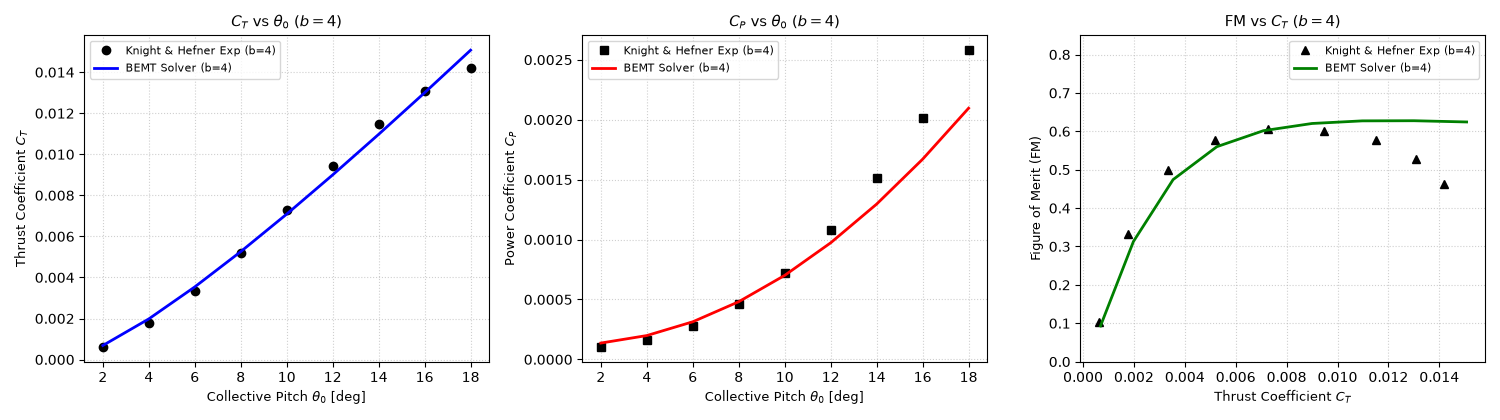

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Knight & Hefner (1937) Baseline (b = 4) ---
R_kh = 0.762          # Rotor Radius [m] 1, 2]
R_rc_kh = 0.125       # Root Cut-out [m] 1, 2]
B_kh = 4              # Number of Blades 1, 2]
c_kh = 0.0508         # Chord Length [m] 1, 2]
rho_sea_level = 1.225 # Air density [kg/m^3]

airfoil_kh = AirfoilModel(
    airfoil_name="Knight & Hefner Analytical",
    cl_slope_fallback=5.75,
    cd0_fallback=0.0113,
    alpha_stall_deg_fallback=14.0
)

cond_kh = FlightCondition(v_axial=0.0, rpm=1200.0, rho=rho_sea_level)

# --- 2. Digitized & Reconciled NACA TN 626 Experimental Data (b = 4) ---
exp_theta_deg = np.array([2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0])

# Converted from NACA TN 626 (divided by pi^3/4 and pi^4/8) 2]
exp_ct_b4 = np.array([0.00062, 0.00178, 0.00335, 0.00520, 0.00728, 0.00945, 0.01150, 0.01310, 0.01420])
exp_cp_b4 = np.array([0.000105, 0.000160, 0.000275, 0.000460, 0.000725, 0.001080, 0.001510, 0.002010, 0.002580])
exp_fm_b4 = (exp_ct_b4 ** 1.5) / (np.sqrt(2.0) * exp_cp_b4)

# --- 3. Evaluate BEMT Solver ---
bemt_ct, bemt_cp, bemt_fm = [], [], []

for th in exp_theta_deg:
    geom = RotorGeometry(
        radius=R_kh,
        root_cutout=R_rc_kh,
        num_blades=B_kh,
        chord_func=lambda r: c_kh,
        twist_func=lambda r: np.radians(th)
    )
    res = run_bemt(geom, cond_kh, airfoil_kh, num_elements=50)
    bemt_ct.append(res.ct)
    bemt_cp.append(res.cp)
    bemt_fm.append(res.figure_of_merit)

bemt_ct = np.array(bemt_ct)
bemt_cp = np.array(bemt_cp)
bemt_fm = np.array(bemt_fm)

# --- 4. Error Metrics ---
rmse_ct = np.sqrt(np.mean((bemt_ct - exp_ct_b4)**2))
mae_ct = np.mean(np.abs(bemt_ct - exp_ct_b4))

rmse_cp = np.sqrt(np.mean((bemt_cp - exp_cp_b4)**2))
mae_cp = np.mean(np.abs(bemt_cp - exp_cp_b4))

print("=" * 60)
print(f"BEMT Validation Summary vs Knight & Hefner (1937) [b = {B_kh}]")
print("=" * 60)
print(f"Thrust Coefficient (C_T) -> RMSE: {rmse_ct:.6f} | MAE: {mae_ct:.6f}")
print(f"Power Coefficient  (C_P) -> RMSE: {rmse_cp:.6f} | MAE: {mae_cp:.6f}")
print("=" * 60)

# --- 5. Plots ---
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2), dpi=100)

axs[0].plot(exp_theta_deg, exp_ct_b4, 'ko', markersize=6, label='Knight & Hefner Exp (b=4)')
axs[0].plot(exp_theta_deg, bemt_ct, 'b-', lw=2, label='BEMT Solver (b=4)')
axs[0].set_xlabel(r'Collective Pitch $\theta_0$ [deg]', fontsize=9.5)
axs[0].set_ylabel(r'Thrust Coefficient $C_T$', fontsize=9.5)
axs[0].set_title(r'$C_T$ vs $\theta_0$ ($b=4$)', fontsize=10.5)
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].legend(fontsize=8)

axs[1].plot(exp_theta_deg, exp_cp_b4, 'ks', markersize=6, label='Knight & Hefner Exp (b=4)')
axs[1].plot(exp_theta_deg, bemt_cp, 'r-', lw=2, label='BEMT Solver (b=4)')
axs[1].set_xlabel(r'Collective Pitch $\theta_0$ [deg]', fontsize=9.5)
axs[1].set_ylabel(r'Power Coefficient $C_P$', fontsize=9.5)
axs[1].set_title(r'$C_P$ vs $\theta_0$ ($b=4$)', fontsize=10.5)
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend(fontsize=8)

axs[2].plot(exp_ct_b4, exp_fm_b4, 'k^', markersize=6, label='Knight & Hefner Exp (b=4)')
axs[2].plot(bemt_ct, bemt_fm, 'g-', lw=2, label='BEMT Solver (b=4)')
axs[2].set_xlabel(r'Thrust Coefficient $C_T$', fontsize=9.5)
axs[2].set_ylabel('Figure of Merit (FM)', fontsize=9.5)
axs[2].set_title(r'$\mathrm{FM}$ vs $C_T$ ($b=4$)', fontsize=10.5)
axs[2].set_ylim(0, 0.85)
axs[2].grid(True, linestyle=':', alpha=0.6)
axs[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

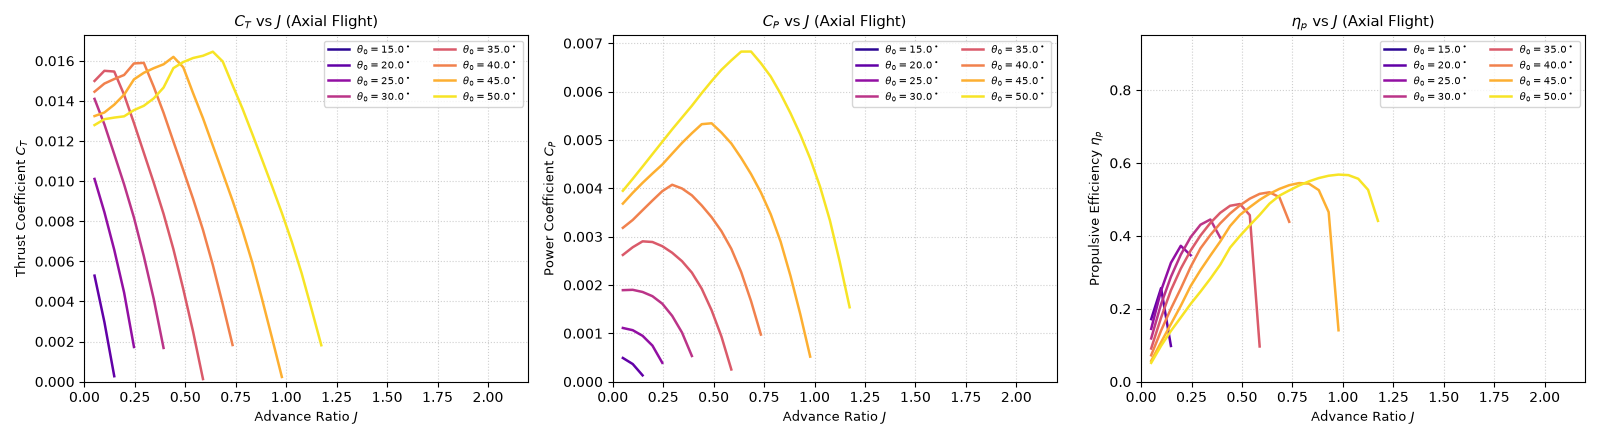

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Rotor & Operating Baseline for Axial Cruise (Task 7) ---
R_cruise = 0.762          # Rotor radius [m][cite: 1, 2]
R_rc_cruise = 0.125       # Root cutout [m][cite: 1, 2]
B_cruise = 4              # Number of blades[cite: 1, 2]
c_cruise = 0.0508         # Chord [m][cite: 1, 2]
rpm_cruise = 1200.0       # Cruise RPM[cite: 1, 2]
rho_cruise = 1.225        # Density [kg/m^3][cite: 1]

airfoil_cruise = AirfoilModel(
    airfoil_name="NACA 0012",
    cl_slope_fallback=5.75,
    cd0_fallback=0.0113,
    alpha_stall_deg_fallback=14.0
)

# --- 2. Advance Ratio Sweep Setup (Capped to J = 2.2) ---
n_rps = rpm_cruise / 60.0
D_rotor = 2.0 * R_cruise

# Extended collective range for high advance ratios (J up to 2.2)
collective_settings_deg = [15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0]
blade_twist_deg = -15.0  # Linear aerodynamic washout

# Sweep axial advance ratio J from 0.05 to 2.2
j_sweep = np.linspace(0.05, 2.2, 45)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.4), dpi=100)
colors = plt.cm.plasma(np.linspace(0.05, 0.95, len(collective_settings_deg)))

for idx, theta_0 in enumerate(collective_settings_deg):
    ct_vals, cp_vals, eta_vals = [], [], []
    
    for J in j_sweep:
        v_axial = J * n_rps * D_rotor
        
        cond_axial = FlightCondition(v_axial=v_axial, rpm=rpm_cruise, rho=rho_cruise)
        geom_axial = RotorGeometry(
            radius=R_cruise,
            root_cutout=R_rc_cruise,
            num_blades=B_cruise,
            chord_func=lambda r: c_cruise,
            twist_func=lambda r: np.radians(theta_0 + blade_twist_deg * (r / R_cruise))
        )
        
        res = run_bemt(geom_axial, cond_axial, airfoil_cruise, num_elements=40)
        
        # Filter negative thrust regions (windmilling/drag regime)
        if res.ct >= 0 and res.cp > 0:
            ct_vals.append(res.ct)
            cp_vals.append(res.cp)
            eta_vals.append(res.propulsive_eff)
        else:
            ct_vals.append(np.nan)
            cp_vals.append(np.nan)
            eta_vals.append(np.nan)
            
    c = colors[idx]
    lbl = rf'$\theta_0 = {theta_0}^\circ$'
    
    # (a) C_T vs J
    axs[0].plot(j_sweep, ct_vals, '-', color=c, lw=1.8, label=lbl)
    
    # (b) C_P vs J
    axs[1].plot(j_sweep, cp_vals, '-', color=c, lw=1.8, label=lbl)
    
    # (c) eta_p vs J
    axs[2].plot(j_sweep, eta_vals, '-', color=c, lw=1.8, label=lbl)

# --- 3. Graph Formatting ---
axs[0].set_xlabel('Advance Ratio $J$', fontsize=9.5)
axs[0].set_ylabel('Thrust Coefficient $C_T$', fontsize=9.5)
axs[0].set_title(r'$C_T$ vs $J$ (Axial Flight)', fontsize=10.5)
axs[0].set_xlim(0, 2.2)
axs[0].set_ylim(bottom=0.0)
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].legend(fontsize=7.5, ncol=2)

axs[1].set_xlabel('Advance Ratio $J$', fontsize=9.5)
axs[1].set_ylabel('Power Coefficient $C_P$', fontsize=9.5)
axs[1].set_title(r'$C_P$ vs $J$ (Axial Flight)', fontsize=10.5)
axs[1].set_xlim(0, 2.2)
axs[1].set_ylim(bottom=0.0)
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend(fontsize=7.5, ncol=2)

axs[2].set_xlabel('Advance Ratio $J$', fontsize=9.5)
axs[2].set_ylabel(r'Propulsive Efficiency $\eta_p$', fontsize=9.5)
axs[2].set_title(r'$\eta_p$ vs $J$ (Axial Flight)', fontsize=10.5)
axs[2].set_xlim(0, 2.2)
axs[2].set_ylim(0.0, 0.95)
axs[2].grid(True, linestyle=':', alpha=0.6)
axs[2].legend(fontsize=7.5, ncol=2)

plt.tight_layout()
plt.show()

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Enable interactive matplotlib backend if running in standard Jupyter/Colab
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

# ==============================================================================
# 1. PARAMETRIC SLIDER DEFINITIONS (FULL USER CONTROL)
# ==============================================================================

# --- Vehicle Mass & Weights ---
w_mtow = widgets.FloatSlider(value=10500.0, min=2000.0, max=25000.0, step=100.0, description='MTOW [kg]:', continuous_update=False)
w_empty_frac = widgets.FloatSlider(value=0.58, min=0.35, max=0.75, step=0.01, description='Empty Mass %:', continuous_update=False)
w_fuel_frac = widgets.FloatSlider(value=0.25, min=0.10, max=0.45, step=0.01, description='Fuel Mass %:', continuous_update=False)

# --- Main Wing Planform ---
w_wing_area = widgets.FloatSlider(value=32.0, min=5.0, max=80.0, step=0.5, description='Wing Area [m²]:', continuous_update=False)
w_aspect_ratio = widgets.FloatSlider(value=7.8, min=4.0, max=16.0, step=0.1, description='Aspect Ratio:', continuous_update=False)
w_taper_ratio = widgets.FloatSlider(value=0.65, min=0.2, max=1.0, step=0.05, description='Taper Ratio:', continuous_update=False)
w_sweep_deg = widgets.FloatSlider(value=2.5, min=-10.0, max=35.0, step=0.5, description='Sweep [deg]:', continuous_update=False)

# --- Rotor / Proprotor Geometry ---
w_num_rotors = widgets.IntSlider(value=2, min=1, max=6, step=1, description='No. of Rotors:', continuous_update=False)
w_rotor_radius = widgets.FloatSlider(value=4.25, min=0.5, max=8.0, step=0.05, description='Rotor Rad [m]:', continuous_update=False)
w_num_blades = widgets.IntSlider(value=3, min=2, max=6, step=1, description='Blades/Rotor:', continuous_update=False)
w_blade_chord = widgets.FloatSlider(value=0.38, min=0.05, max=1.0, step=0.01, description='Blade Chord [m]:', continuous_update=False)
w_rpm_hover = widgets.FloatSlider(value=440.0, min=100.0, max=2000.0, step=10.0, description='Hover RPM:', continuous_update=False)
w_rpm_cruise = widgets.FloatSlider(value=360.0, min=100.0, max=2000.0, step=10.0, description='Cruise RPM:', continuous_update=False)

# --- Fuselage & Empennage ---
w_fuse_length = widgets.FloatSlider(value=14.5, min=3.0, max=30.0, step=0.25, description='Fuse Len [m]:', continuous_update=False)
w_fuse_width = widgets.FloatSlider(value=2.1, min=0.5, max=5.0, step=0.1, description='Fuse Width [m]:', continuous_update=False)
w_htail_vol = widgets.FloatSlider(value=0.85, min=0.2, max=1.5, step=0.05, description='H-Tail Vol Coeff:', continuous_update=False)
w_vtail_vol = widgets.FloatSlider(value=0.06, min=0.01, max=0.15, step=0.005, description='V-Tail Vol Coeff:', continuous_update=False)

# --- Aerodynamics & Propulsion ---
w_cd0 = widgets.FloatSlider(value=0.024, min=0.010, max=0.060, step=0.001, description='Airframe CD0:', continuous_update=False)
w_oswald_e = widgets.FloatSlider(value=0.82, min=0.60, max=0.95, step=0.01, description='Oswald Eff (e):', continuous_update=False)
w_cl_max = widgets.FloatSlider(value=1.65, min=1.0, max=2.8, step=0.05, description='Wing CL_max:', continuous_update=False)
w_engine_power = widgets.FloatSlider(value=4800.0, min=500.0, max=15000.0, step=100.0, description='Inst Power [kW]:', continuous_update=False)
w_sfc = widgets.FloatSlider(value=0.285, min=0.15, max=0.60, step=0.005, description='SFC [kg/kW/hr]:', continuous_update=False)
w_cruise_alt = widgets.FloatSlider(value=2500.0, min=0.0, max=8000.0, step=100.0, description='Cruise Alt [m]:', continuous_update=False)

# Style formatting for all widget labels
slider_style = {'description_width': '140px'}
slider_layout = widgets.Layout(width='95%')

all_sliders = [
    w_mtow, w_empty_frac, w_fuel_frac, w_wing_area, w_aspect_ratio,
    w_taper_ratio, w_sweep_deg, w_num_rotors, w_rotor_radius, w_num_blades,
    w_blade_chord, w_rpm_hover, w_rpm_cruise, w_fuse_length, w_fuse_width,
    w_htail_vol, w_vtail_vol, w_cd0, w_oswald_e, w_cl_max, w_engine_power,
    w_sfc, w_cruise_alt
]

for s in all_sliders:
    s.style = slider_style
    s.layout = slider_layout

# ==============================================================================
# 2. PARAMETRIC AERODYNAMICS & SIZING ENGINE
# ==============================================================================

def isa_atmosphere(altitude_m):
    """Calculates density, speed of sound, and temperature up to 11 km."""
    alt = np.clip(altitude_m, 0.0, 11000.0)
    T = 288.15 - 0.0065 * alt
    P = 101325.0 * ((T / 288.15) ** 5.2561)
    rho = P / (287.058 * T)
    a = np.sqrt(1.4 * 287.058 * T)
    return rho, a, T

def update_aircraft_design(
    mtow, empty_frac, fuel_frac, s_wing, ar_wing, lambda_wing, sweep_deg,
    n_rotors, r_rotor, n_blades, c_blade, rpm_h, rpm_c, l_fuse, w_fuse,
    vh_tail, vv_tail, cd0, e_oswald, cl_max, p_inst_kw, sfc_hr, cruise_alt
):
    # --- Masses & Balances ---
    m_empty = mtow * empty_frac
    m_fuel = mtow * fuel_frac
    m_payload = mtow - m_empty - m_fuel
    weight_n = mtow * 9.80665

    # --- Wing Geometry Calculations ---
    b_wing = np.sqrt(s_wing * ar_wing)
    c_root = (2.0 * s_wing) / (b_wing * (1.0 + lambda_wing))
    c_tip = c_root * lambda_wing
    mac = (2.0 / 3.0) * c_root * (1.0 + lambda_wing + lambda_wing**2) / (1.0 + lambda_wing)

    # --- Empennage Sizing via Volume Coefficients ---
    l_tail_arm = 0.45 * l_fuse
    s_htail = (vh_tail * s_wing * mac) / l_tail_arm
    s_vtail = (vv_tail * s_wing * b_wing) / l_tail_arm

    # --- Rotor Disk & Disk Loading ---
    disk_area_single = np.pi * (r_rotor ** 2)
    total_disk_area = n_rotors * disk_area_single
    rotor_solidity = (n_blades * c_blade) / (np.pi * r_rotor)
    disk_loading_hover = weight_n / total_disk_area

    # --- Atmosphere at Sea Level & Cruise ---
    rho_sl, a_sl, _ = isa_atmosphere(0.0)
    rho_cr, a_cr, _ = isa_atmosphere(cruise_alt)

    # --- Tip Mach Numbers ---
    v_tip_hover = (rpm_h * 2.0 * np.pi / 60.0) * r_rotor
    tip_mach_hover = v_tip_hover / a_sl

    # --- Forward Flight Drag & Power Curve (Airplane Mode Cruise) ---
    v_stall = np.sqrt((2.0 * weight_n) / (rho_cr * s_wing * cl_max))
    v_vec = np.linspace(v_stall * 1.05, 180.0, 150) # m/s
    q_vec = 0.5 * rho_cr * (v_vec ** 2)

    cl_vec = weight_n / (q_vec * s_wing)
    cd_ind_vec = (cl_vec ** 2) / (np.pi * ar_wing * e_oswald)
    cd_total_vec = cd0 + cd_ind_vec
    drag_vec = q_vec * s_wing * cd_total_vec

    # Propulsive power required in airplane mode (assumes typical 82% propulsive efficiency)
    p_req_aero_kw = (drag_vec * v_vec) / (0.82 * 1000.0)
    
    # Hover Induced & Profile Power per Ideal Momentum + Empirical Profile drag
    p_hov_ideal_kw = (weight_n * np.sqrt(weight_n / (2.0 * rho_sl * total_disk_area))) / 1000.0
    cd0_blade = 0.012
    p_hov_profile_kw = (n_rotors * (1.0 / 8.0) * rho_sl * total_disk_area * (v_tip_hover**3) * rotor_solidity * cd0_blade) / 1000.0
    p_hov_total_kw = (1.15 * p_hov_ideal_kw + p_hov_profile_kw) / 0.94 # 94% transmission eff

    # Best L/D and max range point
    ld_vec = cl_vec / cd_total_vec
    idx_max_ld = np.argmax(ld_vec)
    v_best_ld = v_vec[idx_max_ld]
    max_ld = ld_vec[idx_max_ld]
    p_at_best_ld = p_req_aero_kw[idx_max_ld]

    # Max speed where P_req == P_inst (derated with altitude)
    p_avail_cr_kw = p_inst_kw * (rho_cr / rho_sl) ** 1.05
    feasible_v = v_vec[p_req_aero_kw <= p_avail_cr_kw]
    v_max = feasible_v[-1] if len(feasible_v) > 0 else 0.0

    # Breguet Range Estimation at Best L/D
    sfc_si = sfc_hr / (3.6e6) # kg/(W*s)
    # Range = (eta / SFC_thrust) * L/D * ln(W0/W1)
    # Using specific fuel consumption on shaft power:
    eta_prop = 0.82
    range_km = (eta_prop / (9.80665 * (sfc_si * 1000.0))) * (v_best_ld * 3.6 / 3.6) * max_ld * np.log(mtow / (mtow - m_fuel)) / 1000.0

    # ==============================================================================
    # 3. LIVE GRAPHICAL DISPLAY & 2D SCHEMATIC RENDERING
    # ==============================================================================
    fig = plt.figure(figsize=(16, 7.5))
    gs = fig.add_gridspec(2, 3, width_ratios=[1.4, 1.0, 1.0], hspace=0.35, wspace=0.32)

    ax_cad = fig.add_subplot(gs[:, 0])
    ax_power = fig.add_subplot(gs[0, 1])
    ax_polar = fig.add_subplot(gs[1, 1])
    ax_hud = fig.add_subplot(gs[:, 2])

    # --- 1. Top-View Parametric CAD Schematic ---
    ax_cad.set_aspect('equal')
    ax_cad.set_title("Parametric Top-View General Arrangement", fontsize=11, fontweight='bold')
    ax_cad.set_xlabel("X-station [m]")
    ax_cad.set_ylabel("Spanwise Y [m]")
    ax_cad.grid(True, linestyle=':', alpha=0.6)

    # Fuselage Outline
    fuse_x = np.array([0, 0.15*l_fuse, 0.7*l_fuse, l_fuse, 0.7*l_fuse, 0.15*l_fuse, 0])
    fuse_y = np.array([0, 0.5*w_fuse, 0.5*w_fuse, 0, -0.5*w_fuse, -0.5*w_fuse, 0])
    ax_cad.plot(fuse_x, fuse_y, 'k-', lw=2, label='Fuselage')
    ax_cad.fill(fuse_x, fuse_y, color='#e9ecef', alpha=0.8)

    # Main Wing (Trapezoidal with Sweep)
    wing_x_le = 0.35 * l_fuse
    x_offset_tip = 0.5 * b_wing * np.tan(np.radians(sweep_deg))
    w_x = np.array([
        wing_x_le, 
        wing_x_le + x_offset_tip, 
        wing_x_le + x_offset_tip + c_tip, 
        wing_x_le + c_root, 
        wing_x_le + x_offset_tip + c_tip, 
        wing_x_le + x_offset_tip, 
        wing_x_le
    ])
    w_y = np.array([0, 0.5*b_wing, 0.5*b_wing, 0, -0.5*b_wing, -0.5*b_wing, 0])
    ax_cad.plot(w_x, w_y, 'b-', lw=2, label='Main Wing')
    ax_cad.fill(w_x, w_y, color='#cfe2ff', alpha=0.7)

    # Horizontal Tail
    b_htail = np.sqrt(s_htail * 4.5)
    c_htail = s_htail / b_htail
    ht_x_le = wing_x_le + l_tail_arm
    ht_x = [ht_x_le, ht_x_le, ht_x_le + c_htail, ht_x_le + c_htail]
    ht_y = [-0.5*b_htail, 0.5*b_htail, 0.5*b_htail, -0.5*b_htail]
    ax_cad.fill(ht_x, ht_y, color='#adb5bd', alpha=0.7, label='H-Tail')

    # Twin Proprotor Tip Disks
    if n_rotors == 2:
        rotor_centers = [(wing_x_le + x_offset_tip, 0.5*b_wing), (wing_x_le + x_offset_tip, -0.5*b_wing)]
    else:
        rotor_y_pos = np.linspace(-0.45*b_wing, 0.45*b_wing, n_rotors)
        rotor_centers = [(wing_x_le + 0.5*c_root, y_pos) for y_pos in rotor_y_pos]

    for idx, (rx, ry) in enumerate(rotor_centers):
        circle = plt.Circle((rx, ry), r_rotor, color='crimson', fill=False, linestyle='--', lw=1.5)
        ax_cad.add_patch(circle)
        ax_cad.plot(rx, ry, 'ro', ms=4)

    ax_cad.set_xlim(-1.0, l_fuse + 2.0)
    ax_cad.set_ylim(-0.6*b_wing - r_rotor, 0.6*b_wing + r_rotor)

    # --- 2. Aerodynamic Power Curve ---
    ax_power.plot(v_vec * 3.6, p_req_aero_kw, 'r-', lw=2, label='Power Required (Cruise)')
    ax_power.axhline(p_avail_cr_kw, color='k', linestyle='--', lw=1.5, label=f'Power Available @ {cruise_alt:.0f}m')
    ax_power.axvline(v_stall * 3.6, color='goldenrod', linestyle=':', lw=1.5, label=f'Stall Speed ({v_stall*3.6:.1f} km/h)')
    ax_power.plot(v_best_ld * 3.6, p_at_best_ld, 'go', ms=6, label=f'Best L/D Speed ({v_best_ld*3.6:.1f} km/h)')
    ax_power.set_title("Airplane Cruise Mode: Power vs Speed", fontsize=10)
    ax_power.set_xlabel("True Airspeed [km/h]")
    ax_power.set_ylabel("Power [kW]")
    ax_power.grid(True, linestyle=':', alpha=0.6)
    ax_power.legend(fontsize=7.5, loc='upper left')

    # --- 3. Drag Polar & L/D Profile ---
    ax_polar.plot(v_vec * 3.6, ld_vec, 'g-', lw=2, label='Lift-to-Drag Ratio (L/D)')
    ax_polar.plot(v_best_ld * 3.6, max_ld, 'k*', ms=9, label=f'Max L/D = {max_ld:.2f}')
    ax_polar.set_title("Aerodynamic Efficiency: L/D vs Airspeed", fontsize=10)
    ax_polar.set_xlabel("True Airspeed [km/h]")
    ax_polar.set_ylabel("L/D Ratio")
    ax_polar.grid(True, linestyle=':', alpha=0.6)
    ax_polar.legend(fontsize=8, loc='lower right')

    # --- 4. HUD Telemetry Card & Sizing Metrics ---
    ax_hud.axis('off')
    hud_text = (
        f"AIRCRAFT DESIGN TELEMETRY\n"
        f"-----------------------------------------\n"
        f"WEIGHT BREAKDOWN:\n"
        f"  • MTOW:           {mtow:8.1f} kg\n"
        f"  • Operating Empty:{m_empty:8.1f} kg ({empty_frac*100:.1f}%)\n"
        f"  • Usable Fuel:    {m_fuel:8.1f} kg ({fuel_frac*100:.1f}%)\n"
        f"  • Payload:        {m_payload:8.1f} kg\n\n"
        f"WING PLANFORM:\n"
        f"  • Wing Span:      {b_wing:8.2f} m\n"
        f"  • Wing Loading:   {weight_n/s_wing:8.1f} N/m²\n"
        f"  • Root Chord:     {c_root:8.2f} m\n"
        f"  • Tip Chord:      {c_tip:8.2f} m\n"
        f"  • Mean Aero Chord:{mac:8.2f} m\n\n"
        f"ROTOR SYSTEM ({n_rotors} Rotors, {n_blades} Blades):\n"
        f"  • Total Disk Area:{total_disk_area:8.2f} m²\n"
        f"  • Disk Loading:   {disk_loading_hover:8.1f} N/m²\n"
        f"  • Rotor Solidity: {rotor_solidity:8.3f}\n"
        f"  • Hover Tip Mach: {tip_mach_hover:8.2f}\n"
        f"  • Hover Power:    {p_hov_total_kw:8.1f} kW\n\n"
        f"PERFORMANCE METRICS:\n"
        f"  • Max Speed (Alt):{v_max*3.6:8.1f} km/h\n"
        f"  • Best L/D Speed: {v_best_ld*3.6:8.1f} km/h\n"
        f"  • Max L/D Ratio:  {max_ld:8.2f}\n"
        f"  • Estimated Range:{range_km:8.1f} km"
    )
    ax_hud.text(0.05, 0.95, hud_text, fontfamily='monospace', fontsize=9.2, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#ced4da', lw=1.2))

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 4. INTERACTIVE USER INTERFACE CONSTRUCT
# ==============================================================================

out_interactive = widgets.interactive_output(
    update_aircraft_design,
    {
        'mtow': w_mtow, 'empty_frac': w_empty_frac, 'fuel_frac': w_fuel_frac,
        's_wing': w_wing_area, 'ar_wing': w_aspect_ratio, 'lambda_wing': w_taper_ratio,
        'sweep_deg': w_sweep_deg, 'n_rotors': w_num_rotors, 'r_rotor': w_rotor_radius,
        'n_blades': w_num_blades, 'c_blade': w_blade_chord, 'rpm_h': w_rpm_hover,
        'rpm_c': w_rpm_cruise, 'l_fuse': w_fuse_length, 'w_fuse': w_fuse_width,
        'vh_tail': w_htail_vol, 'vv_tail': w_vtail_vol, 'cd0': w_cd0,
        'e_oswald': w_oswald_e, 'cl_max': w_cl_max, 'p_inst_kw': w_engine_power,
        'sfc_hr': w_sfc, 'cruise_alt': w_cruise_alt
    }
)

panel_weights = widgets.VBox([widgets.HTML("<b>Masses & Weight Fractions</b>"), w_mtow, w_empty_frac, w_fuel_frac])
panel_wing = widgets.VBox([widgets.HTML("<b>Main Wing Planform</b>"), w_wing_area, w_aspect_ratio, w_taper_ratio, w_sweep_deg])
panel_rotors = widgets.VBox([widgets.HTML("<b>Rotors & Dynamics</b>"), w_num_rotors, w_rotor_radius, w_num_blades, w_blade_chord, w_rpm_hover, w_rpm_cruise])
panel_fuselage = widgets.VBox([widgets.HTML("<b>Fuselage & Tail Sizing</b>"), w_fuse_length, w_fuse_width, w_htail_vol, w_vtail_vol])
panel_aero_prop = widgets.VBox([widgets.HTML("<b>Aero & Propulsion Engine</b>"), w_cd0, w_oswald_e, w_cl_max, w_engine_power, w_sfc, w_cruise_alt])

controls_accordion = widgets.Accordion(children=[panel_weights, panel_wing, panel_rotors, panel_fuselage, panel_aero_prop])
controls_accordion.set_title(0, "Mass & Weights")
controls_accordion.set_title(1, "Wing Geometry")
controls_accordion.set_title(2, "Rotor Configuration")
controls_accordion.set_title(3, "Fuselage & Empennage")
controls_accordion.set_title(4, "Aero & Propulsion")

display(widgets.VBox([controls_accordion, out_interactive]))

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
from dataclasses import dataclass
from typing import List, Tuple, Dict
from enum import Enum

# ==============================================================================
# 1. ATMOSPHERE & MISSION DATA STRUCTURES
# ==============================================================================

def isa_atmosphere(altitude_m: float) -> Tuple[float, float, float]:
    alt = np.clip(altitude_m, 0.0, 11000.0)
    T = 288.15 - 0.0065 * alt
    P = 101325.0 * ((T / 288.15) ** 5.2561)
    rho = P / (287.058 * T)
    a = np.sqrt(1.4 * 287.058 * T)
    return rho, a, T

class SegmentType(Enum):
    HOVER = "Hover"
    VERTICAL_CLIMB = "Vertical Climb"
    VERTICAL_DESCENT = "Vertical Descent"
    CRUISE = "Cruise (Axial)"
    LOITER = "Loiter"

@dataclass
class MissionLeg:
    name: str
    seg_type: SegmentType
    duration_min: float = 0.0
    distance_km: float = 0.0
    speed_kmh: float = 0.0
    target_alt_m: float = 0.0
    climb_rate_ms: float = 0.0
    rpm: float = 440.0
    wind_kmh: float = 0.0

NUM_ROTORS = 2

# Preset Library
MISSION_PRESETS: Dict[str, List[MissionLeg]] = {
    "-- Custom / Blank --": [],
    "Simple Point-to-Point": [
        MissionLeg("Hover Takeoff", SegmentType.HOVER, duration_min=1.5, target_alt_m=0.0, rpm=440.0),
        MissionLeg("Vertical Climb", SegmentType.VERTICAL_CLIMB, target_alt_m=2000.0, climb_rate_ms=5.0, rpm=440.0),
        MissionLeg("Outbound Cruise", SegmentType.CRUISE, distance_km=200.0, speed_kmh=420.0, target_alt_m=2000.0, rpm=365.0, wind_kmh=0.0),
        MissionLeg("Vertical Descent", SegmentType.VERTICAL_DESCENT, target_alt_m=0.0, climb_rate_ms=-3.5, rpm=440.0),
        MissionLeg("Landing Hover", SegmentType.HOVER, duration_min=1.5, target_alt_m=0.0, rpm=440.0),
    ],
    "Mission with Loiter / ISR": [
        MissionLeg("Hover Takeoff", SegmentType.HOVER, duration_min=1.5, target_alt_m=0.0, rpm=440.0),
        MissionLeg("Climb to Cruise", SegmentType.VERTICAL_CLIMB, target_alt_m=2500.0, climb_rate_ms=5.0, rpm=440.0),
        MissionLeg("Dash Inbound", SegmentType.CRUISE, distance_km=150.0, speed_kmh=440.0, target_alt_m=2500.0, rpm=365.0, wind_kmh=15.0),
        MissionLeg("On-Station Loiter", SegmentType.LOITER, duration_min=30.0, speed_kmh=260.0, target_alt_m=2500.0, rpm=365.0),
        MissionLeg("Return Cruise", SegmentType.CRUISE, distance_km=150.0, speed_kmh=420.0, target_alt_m=2500.0, rpm=365.0, wind_kmh=-15.0),
        MissionLeg("Vertical Descent", SegmentType.VERTICAL_DESCENT, target_alt_m=0.0, climb_rate_ms=-3.5, rpm=440.0),
        MissionLeg("Landing Hover", SegmentType.HOVER, duration_min=1.5, target_alt_m=0.0, rpm=440.0),
    ],
    "Tactical Medevac / Pax Transport": [
        MissionLeg("Rapid Takeoff", SegmentType.HOVER, duration_min=1.0, target_alt_m=0.0, rpm=440.0),
        MissionLeg("Climb Out", SegmentType.VERTICAL_CLIMB, target_alt_m=2500.0, climb_rate_ms=6.0, rpm=440.0),
        MissionLeg("Inbound Transit", SegmentType.CRUISE, distance_km=180.0, speed_kmh=450.0, target_alt_m=2500.0, rpm=365.0, wind_kmh=0.0),
        MissionLeg("Descent to LZ", SegmentType.VERTICAL_DESCENT, target_alt_m=100.0, climb_rate_ms=-4.0, rpm=440.0),
        MissionLeg("Boarding / Hover", SegmentType.HOVER, duration_min=3.0, target_alt_m=100.0, rpm=440.0),
        MissionLeg("Climb to Return Alt", SegmentType.VERTICAL_CLIMB, target_alt_m=2500.0, climb_rate_ms=5.5, rpm=440.0),
        MissionLeg("Outbound Transit", SegmentType.CRUISE, distance_km=180.0, speed_kmh=450.0, target_alt_m=2500.0, rpm=365.0, wind_kmh=0.0),
        MissionLeg("Final Descent", SegmentType.VERTICAL_DESCENT, target_alt_m=0.0, climb_rate_ms=-3.5, rpm=440.0),
        MissionLeg("Landing Hover", SegmentType.HOVER, duration_min=1.0, target_alt_m=0.0, rpm=440.0),
    ]
}

mission_schedule: List[MissionLeg] = []

# ==============================================================================
# 2. VEHICLE PARAMETRIC SLIDERS
# ==============================================================================

slider_style = {'description_width': '135px'}
slider_layout = widgets.Layout(width='100%')

# Mass & Payload
w_mtow = widgets.FloatSlider(value=10500.0, min=2000.0, max=25000.0, step=100.0, description='MTOW [kg]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_empty_frac = widgets.FloatSlider(value=0.55, min=0.35, max=0.75, step=0.01, description='Empty Mass %:', style=slider_style, layout=slider_layout, continuous_update=False)
w_fuel_frac = widgets.FloatSlider(value=0.25, min=0.05, max=0.45, step=0.01, description='Fuel Mass %:', style=slider_style, layout=slider_layout, continuous_update=False)
w_payload_mass = widgets.FloatSlider(value=1440.0, min=0.0, max=6000.0, step=20.0, description='Payload [kg]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_reserve_fuel = widgets.FloatSlider(value=300.0, min=50.0, max=800.0, step=25.0, description='Reserve Fuel [kg]:', style=slider_style, layout=slider_layout, continuous_update=False)

# Planform
w_wing_area = widgets.FloatSlider(value=32.0, min=6.0, max=80.0, step=0.5, description='Wing Area [m²]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_aspect_ratio = widgets.FloatSlider(value=7.8, min=4.0, max=16.0, step=0.1, description='Aspect Ratio:', style=slider_style, layout=slider_layout, continuous_update=False)
w_taper_ratio = widgets.FloatSlider(value=0.65, min=0.2, max=1.0, step=0.05, description='Taper Ratio:', style=slider_style, layout=slider_layout, continuous_update=False)
w_sweep_deg = widgets.FloatSlider(value=2.5, min=-10.0, max=35.0, step=0.5, description='Sweep [deg]:', style=slider_style, layout=slider_layout, continuous_update=False)

# Proprotors (Fixed Twin Mount)
w_rotor_radius = widgets.FloatSlider(value=4.25, min=0.5, max=8.0, step=0.05, description='Rotor Rad [m]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_num_blades = widgets.IntSlider(value=3, min=2, max=6, step=1, description='Blades/Rotor:', style=slider_style, layout=slider_layout, continuous_update=False)
w_blade_chord = widgets.FloatSlider(value=0.38, min=0.05, max=1.0, step=0.01, description='Blade Chord [m]:', style=slider_style, layout=slider_layout, continuous_update=False)

# Fuselage & Empennage
w_fuse_length = widgets.FloatSlider(value=14.5, min=4.0, max=30.0, step=0.25, description='Fuse Len [m]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_fuse_width = widgets.FloatSlider(value=2.1, min=0.6, max=5.0, step=0.1, description='Fuse Width [m]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_htail_vol = widgets.FloatSlider(value=0.85, min=0.2, max=1.5, step=0.05, description='H-Tail Vol Coeff:', style=slider_style, layout=slider_layout, continuous_update=False)
w_vtail_vol = widgets.FloatSlider(value=0.06, min=0.01, max=0.15, step=0.005, description='V-Tail Vol Coeff:', style=slider_style, layout=slider_layout, continuous_update=False)

# Aero & Propulsion
w_cd0 = widgets.FloatSlider(value=0.024, min=0.010, max=0.060, step=0.001, description='Airframe CD0:', style=slider_style, layout=slider_layout, continuous_update=False)
w_oswald_e = widgets.FloatSlider(value=0.82, min=0.60, max=0.95, step=0.01, description='Oswald Eff (e):', style=slider_style, layout=slider_layout, continuous_update=False)
w_engine_power = widgets.FloatSlider(value=4800.0, min=500.0, max=15000.0, step=100.0, description='Inst Power [kW]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_sfc = widgets.FloatSlider(value=0.285, min=0.15, max=0.60, step=0.005, description='SFC [kg/kW/hr]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_dt_step = widgets.FloatSlider(value=2.0, min=0.5, max=10.0, step=0.5, description='Sim Step dt [s]:', style=slider_style, layout=slider_layout, continuous_update=False)

# ==============================================================================
# 3. MISSION BUILDER & REAL-TIME IN-PLACE EDITOR
# ==============================================================================

w_preset_dropdown = widgets.Dropdown(
    options=list(MISSION_PRESETS.keys()),
    value="-- Custom / Blank --",
    description='Preset:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='100%')
)

w_seg_dropdown = widgets.Dropdown(
    options=[(t.value, t) for t in SegmentType],
    value=SegmentType.CRUISE,
    description='Leg Type:',
    style={'description_width': '75px'},
    layout=widgets.Layout(width='58%')
)

btn_add_leg = widgets.Button(description="Add Leg", button_style='success', icon='plus', layout=widgets.Layout(width='40%'))
btn_del_leg = widgets.Button(description="Delete Leg", button_style='danger', icon='trash', layout=widgets.Layout(width='48%'))
btn_clear_legs = widgets.Button(description="Clear All", button_style='warning', icon='times', layout=widgets.Layout(width='48%'))

w_mission_list = widgets.Select(
    options=[],
    layout=widgets.Layout(width='100%', height='125px')
)

# In-Place Leg Parameter Edit Fields
w_in_name = widgets.Text(value="Cruise Segment", description='Name:', style={'description_width': '85px'}, layout=widgets.Layout(width='100%'))
w_in_dist = widgets.FloatText(value=150.0, description='Dist [km]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_dur = widgets.FloatText(value=10.0, description='Dur [min]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_speed = widgets.FloatText(value=420.0, description='Speed [km/h]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_alt = widgets.FloatText(value=2500.0, description='Alt [m]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_climb = widgets.FloatText(value=5.0, description='Climb [m/s]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_rpm = widgets.FloatText(value=365.0, description='RPM:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_wind = widgets.FloatText(value=0.0, description='Wind [km/h]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))

# Lock flag to prevent recursive updates between UI events and data model
_is_updating_ui = False

def format_leg_label(idx: int, leg: MissionLeg) -> str:
    if leg.seg_type == SegmentType.HOVER:
        return f"{idx+1}. {leg.name} ({leg.duration_min:.1f}m)"
    elif leg.seg_type in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT]:
        return f"{idx+1}. {leg.name} ({leg.target_alt_m:.0f}m @ {leg.climb_rate_ms:.1f}m/s)"
    elif leg.seg_type == SegmentType.CRUISE:
        return f"{idx+1}. {leg.name} ({leg.distance_km:.0f}km @ {leg.speed_kmh:.0f}km/h)"
    elif leg.seg_type == SegmentType.LOITER:
        return f"{idx+1}. {leg.name} ({leg.duration_min:.1f}m @ {leg.speed_kmh:.0f}km/h)"
    return f"{idx+1}. {leg.name}"

def refresh_mission_list(select_idx=None):
    global _is_updating_ui
    _is_updating_ui = True
    w_mission_list.options = [format_leg_label(i, leg) for i, leg in enumerate(mission_schedule)]
    if mission_schedule:
        if select_idx is not None and 0 <= select_idx < len(mission_schedule):
            w_mission_list.index = select_idx
        elif w_mission_list.index is None or w_mission_list.index >= len(mission_schedule):
            w_mission_list.index = len(mission_schedule) - 1
    else:
        w_mission_list.index = None
    _is_updating_ui = False
    load_selected_leg_into_inputs()

def update_field_visibility(st: SegmentType):
    w_in_dist.layout.display = 'flex' if st == SegmentType.CRUISE else 'none'
    w_in_dur.layout.display = 'flex' if st in [SegmentType.HOVER, SegmentType.LOITER] else 'none'
    w_in_speed.layout.display = 'flex' if st in [SegmentType.CRUISE, SegmentType.LOITER] else 'none'
    w_in_alt.layout.display = 'flex' if st != SegmentType.HOVER else 'none'
    w_in_climb.layout.display = 'flex' if st in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT] else 'none'
    w_in_wind.layout.display = 'flex' if st == SegmentType.CRUISE else 'none'

def load_selected_leg_into_inputs(change=None):
    global _is_updating_ui
    if _is_updating_ui or w_mission_list.index is None or not (0 <= w_mission_list.index < len(mission_schedule)):
        return

    _is_updating_ui = True
    leg = mission_schedule[w_mission_list.index]
    w_seg_dropdown.value = leg.seg_type
    w_in_name.value = leg.name
    w_in_dist.value = leg.distance_km
    w_in_dur.value = leg.duration_min
    w_in_speed.value = leg.speed_kmh
    w_in_alt.value = leg.target_alt_m
    w_in_climb.value = leg.climb_rate_ms
    w_in_rpm.value = leg.rpm
    w_in_wind.value = leg.wind_kmh
    update_field_visibility(leg.seg_type)
    _is_updating_ui = False

w_mission_list.observe(load_selected_leg_into_inputs, names='index')

def on_field_edited(change=None):
    global _is_updating_ui
    if _is_updating_ui or w_mission_list.index is None or not (0 <= w_mission_list.index < len(mission_schedule)):
        return

    idx = w_mission_list.index
    leg = mission_schedule[idx]
    leg.seg_type = w_seg_dropdown.value
    leg.name = w_in_name.value.strip() or f"Leg {idx+1}"
    leg.distance_km = float(w_in_dist.value)
    leg.duration_min = float(w_in_dur.value)
    leg.speed_kmh = float(w_in_speed.value)
    leg.target_alt_m = float(w_in_alt.value)
    leg.climb_rate_ms = float(w_in_climb.value)
    leg.rpm = float(w_in_rpm.value)
    leg.wind_kmh = float(w_in_wind.value)

    update_field_visibility(leg.seg_type)
    
    # Update label in the list widget without resetting index
    _is_updating_ui = True
    current_options = list(w_mission_list.options)
    current_options[idx] = format_leg_label(idx, leg)
    w_mission_list.options = current_options
    _is_updating_ui = False

    solve_aircraft_and_mission()

for w in [w_seg_dropdown, w_in_name, w_in_dist, w_in_dur, w_in_speed, w_in_alt, w_in_climb, w_in_rpm, w_in_wind]:
    w.observe(on_field_edited, names='value')

def on_add_leg(b):
    st = w_seg_dropdown.value
    idx = len(mission_schedule) + 1
    new_leg = MissionLeg(
        name=f"Segment {idx}",
        seg_type=st,
        duration_min=float(w_in_dur.value) if st in [SegmentType.HOVER, SegmentType.LOITER] else 0.0,
        distance_km=float(w_in_dist.value) if st == SegmentType.CRUISE else 0.0,
        speed_kmh=float(w_in_speed.value) if st in [SegmentType.CRUISE, SegmentType.LOITER] else 0.0,
        target_alt_m=float(w_in_alt.value),
        climb_rate_ms=float(w_in_climb.value) if st in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT] else 0.0,
        rpm=float(w_in_rpm.value),
        wind_kmh=float(w_in_wind.value) if st == SegmentType.CRUISE else 0.0
    )
    mission_schedule.append(new_leg)
    refresh_mission_list(select_idx=len(mission_schedule) - 1)
    solve_aircraft_and_mission()

def on_del_leg(b):
    if w_mission_list.index is not None and len(mission_schedule) > 0:
        cur = w_mission_list.index
        mission_schedule.pop(cur)
        new_idx = max(0, cur - 1) if len(mission_schedule) > 0 else None
        refresh_mission_list(select_idx=new_idx)
        solve_aircraft_and_mission()

def on_clear_legs(b):
    mission_schedule.clear()
    refresh_mission_list()
    solve_aircraft_and_mission()

def on_preset_selected(change):
    chosen = w_preset_dropdown.value
    mission_schedule.clear()
    for leg in MISSION_PRESETS[chosen]:
        mission_schedule.append(MissionLeg(
            name=leg.name, seg_type=leg.seg_type, duration_min=leg.duration_min,
            distance_km=leg.distance_km, speed_kmh=leg.speed_kmh, target_alt_m=leg.target_alt_m,
            climb_rate_ms=leg.climb_rate_ms, rpm=leg.rpm, wind_kmh=leg.wind_kmh
        ))
    refresh_mission_list(select_idx=0 if len(mission_schedule) > 0 else None)
    solve_aircraft_and_mission()

btn_add_leg.on_click(on_add_leg)
btn_del_leg.on_click(on_del_leg)
btn_clear_legs.on_click(on_clear_legs)
w_preset_dropdown.observe(on_preset_selected, names='value')

# ==============================================================================
# 4. TABBED SLIDERS & SIDEBAR CONTAINER
# ==============================================================================

tab_sliders = widgets.Tab()
tab_sliders.children = [
    widgets.VBox([w_mtow, w_empty_frac, w_fuel_frac, w_payload_mass, w_reserve_fuel]),
    widgets.VBox([w_wing_area, w_aspect_ratio, w_taper_ratio, w_sweep_deg]),
    widgets.VBox([w_rotor_radius, w_num_blades, w_blade_chord]),
    widgets.VBox([w_fuse_length, w_fuse_width, w_htail_vol, w_vtail_vol]),
    widgets.VBox([w_cd0, w_oswald_e, w_engine_power, w_sfc, w_dt_step])
]
tab_sliders.set_title(0, "Mass & Weights")
tab_sliders.set_title(1, "Wing")
tab_sliders.set_title(2, "Twin Rotors")
tab_sliders.set_title(3, "Fuselage")
tab_sliders.set_title(4, "Engine/Aero")

leg_inputs_grid = widgets.VBox([
    w_in_name,
    widgets.HBox([w_in_alt, w_in_rpm]),
    widgets.HBox([w_in_dist, w_in_dur]),
    widgets.HBox([w_in_speed, w_in_climb]),
    widgets.HBox([w_in_wind])
], layout=widgets.Layout(margin='4px 0'))

mission_manager_box = widgets.VBox([
    widgets.HTML("<b style='color:#0d6efd;'>1. Mission Plan & Live Leg Editor</b>"),
    w_preset_dropdown,
    widgets.HBox([w_seg_dropdown, btn_add_leg], layout=widgets.Layout(width='100%', margin='6px 0 2px 0')),
    leg_inputs_grid,
    w_mission_list,
    widgets.HBox([btn_del_leg, btn_clear_legs], layout=widgets.Layout(width='100%'))
], layout=widgets.Layout(border='1px solid #ced4da', padding='8px', border_radius='6px', margin='0 0 10px 0'))

panel_sidebar = widgets.VBox([
    mission_manager_box,
    widgets.HTML("<b style='color:#198754;'>2. Design Parameters</b>"),
    tab_sliders
], layout=widgets.Layout(width='38%', min_width='360px', padding='6px'))

# ==============================================================================
# 5. RESTORED 4-TAB OUTPUT DISPLAY, MARCHING ENGINE & DIAGNOSTICS
# ==============================================================================

out_cad = widgets.Output()
out_profile = widgets.Output()
out_power = widgets.Output()
out_table = widgets.Output()

display_tabs = widgets.Tab(children=[out_cad, out_profile, out_power, out_table])
display_tabs.set_title(0, "General Arrangement")
display_tabs.set_title(1, "Mission Profile")
display_tabs.set_title(2, "Power & Mach Envelope")
display_tabs.set_title(3, "Telemetry Log")

panel_main_display = widgets.VBox([display_tabs], layout=widgets.Layout(width='62%', padding='4px'))

def solve_aircraft_and_mission(change=None):
    mtow = w_mtow.value
    empty_frac = w_empty_frac.value
    fuel_frac = w_fuel_frac.value
    payload_mass = w_payload_mass.value
    reserve_fuel = w_reserve_fuel.value
    s_wing = w_wing_area.value
    ar_wing = w_aspect_ratio.value
    taper = w_taper_ratio.value
    sweep_deg = w_sweep_deg.value
    r_rotor = w_rotor_radius.value
    n_blades = w_num_blades.value
    c_blade = w_blade_chord.value
    l_fuse = w_fuse_length.value
    w_fuse = w_fuse_width.value
    vh_tail = w_htail_vol.value
    cd0 = w_cd0.value
    oswald_e = w_oswald_e.value
    p_inst_kw = w_engine_power.value
    sfc_hr = w_sfc.value
    dt = w_dt_step.value

    m_empty = mtow * empty_frac
    m_fuel_init = mtow * fuel_frac
    takeoff_gross_mass = m_empty + m_fuel_init + payload_mass

    b_wing = np.sqrt(s_wing * ar_wing)
    c_root = (2.0 * s_wing) / (b_wing * (1.0 + taper))
    c_tip = c_root * taper
    mac = (2.0 / 3.0) * c_root * (1.0 + taper + taper**2) / (1.0 + taper)

    l_arm = 0.45 * l_fuse
    s_htail = (vh_tail * s_wing * mac) / l_arm
    disk_area_total = NUM_ROTORS * np.pi * (r_rotor ** 2)
    solidity = (n_blades * c_blade) / (np.pi * r_rotor)

    # Collision audit
    y_tip_rotor = 0.5 * b_wing
    fuse_clearance = (y_tip_rotor - r_rotor) - (0.5 * w_fuse)
    inter_rotor_clearance = 2.0 * (y_tip_rotor - r_rotor)
    
    collision_warn = False
    collision_msg = ""
    if fuse_clearance <= 0:
        collision_warn = True
        collision_msg = f"CRITICAL: Rotor blade penetrates fuselage boundary by {abs(fuse_clearance):.2f} m!"
    elif fuse_clearance < 0.25:
        collision_warn = True
        collision_msg = f"WARNING: Minimum fuselage clearance dangerously tight ({fuse_clearance:.2f} m < 0.25 m)!"
    elif inter_rotor_clearance < 0:
        collision_warn = True
        collision_msg = f"CRITICAL: Proprotor disks overlap each other by {abs(inter_rotor_clearance):.2f} m!"

    # State Marching Execution
    curr_t, curr_alt, curr_fuel, curr_dist = 0.0, 0.0, m_fuel_init, 0.0
    telemetry = []
    failed = False
    fail_msg = ""

    if len(mission_schedule) > 0:
        for leg in mission_schedule:
            start_alt = curr_alt
            if leg.seg_type in [SegmentType.HOVER, SegmentType.LOITER]:
                dur_s = max(leg.duration_min * 60.0, 1.0)
                v_tas = (leg.speed_kmh / 3.6) if leg.seg_type == SegmentType.LOITER else 0.0
                v_ground = v_tas
                alt_target = curr_alt if leg.seg_type == SegmentType.HOVER else leg.target_alt_m
            elif leg.seg_type in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT]:
                climb_speed = abs(leg.climb_rate_ms) if abs(leg.climb_rate_ms) > 0.1 else 3.0
                dur_s = max(abs(leg.target_alt_m - curr_alt) / climb_speed, 1.0)
                v_tas = climb_speed
                v_ground = 0.0
                alt_target = leg.target_alt_m
            elif leg.seg_type == SegmentType.CRUISE:
                v_tas = max(leg.speed_kmh / 3.6, 15.0)
                v_ground = max(v_tas - (leg.wind_kmh / 3.6), 5.0)
                leg_dist_m = max(leg.distance_km * 1000.0, 100.0)
                dur_s = leg_dist_m / v_ground
                alt_target = leg.target_alt_m

            n_steps = max(int(np.ceil(dur_s / dt)), 1)
            step_dt = dur_s / n_steps
            alt_rate = (alt_target - start_alt) / dur_s if dur_s > 0 else 0.0

            for _ in range(n_steps):
                gross_mass = m_empty + curr_fuel + payload_mass
                w_newtons = gross_mass * 9.80665
                rho, a_sound, _ = isa_atmosphere(curr_alt)
                omega = (leg.rpm * 2.0 * np.pi) / 60.0
                v_tip = omega * r_rotor
                m_tip = np.sqrt(v_tip**2 + v_tas**2) / a_sound

                if leg.seg_type in [SegmentType.HOVER, SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT]:
                    t_req = w_newtons * 1.05
                    v_h_ideal = np.sqrt(t_req / (2.0 * rho * disk_area_total))
                    v_climb_ax = leg.climb_rate_ms if leg.seg_type in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT] else 0.0
                    v_i = 0.5 * (-v_climb_ax + np.sqrt(v_climb_ax**2 + 4.0 * (v_h_ideal**2)))
                    p_ind = 1.15 * t_req * (v_climb_ax + v_i)
                    p_prof = (1.0 / 8.0) * rho * disk_area_total * (v_tip**3) * solidity * 0.012
                    p_req_kw = (p_ind + p_prof) / (0.94 * 1000.0)
                else:
                    q_dyn = 0.5 * rho * (v_tas ** 2)
                    cl = w_newtons / (q_dyn * s_wing)
                    cd_ind = (cl ** 2) / (np.pi * ar_wing * oswald_e)
                    drag_total = q_dyn * s_wing * (cd0 + cd_ind)
                    p_req_kw = (drag_total * v_tas) / (0.84 * 1000.0)

                p_avail_kw = p_inst_kw * ((rho / 1.225) ** 1.05)
                fuel_burn_rate = p_req_kw * (sfc_hr / 3600.0)

                if p_req_kw > p_avail_kw:
                    failed = True; fail_msg = f"Power limit ({p_req_kw:.0f} kW > {p_avail_kw:.0f} kW) in leg: {leg.name}"
                    break
                if curr_fuel <= reserve_fuel:
                    failed = True; fail_msg = f"Reserve breached ({curr_fuel:.1f} kg <= {reserve_fuel:.1f} kg) in leg: {leg.name}"
                    break
                if m_tip > 0.85:
                    failed = True; fail_msg = f"Tip Mach exceeded ({m_tip:.3f} > 0.85) in leg: {leg.name}"
                    break

                curr_fuel -= fuel_burn_rate * step_dt
                curr_alt += alt_rate * step_dt
                curr_dist += (v_ground * step_dt) / 1000.0
                curr_t += step_dt

                telemetry.append({
                    "time_min": curr_t / 60.0, "leg": leg.name, "type": leg.seg_type.value, "alt_m": curr_alt,
                    "gross_kg": gross_mass, "fuel_kg": curr_fuel, "payload_kg": payload_mass,
                    "p_req_kw": p_req_kw, "p_avail_kw": p_avail_kw, "speed_kmh": v_tas * 3.6,
                    "dist_km": curr_dist, "mach_tip": m_tip
                })

            if failed:
                break

    df_res = pd.DataFrame(telemetry)

    # --- TAB 0: CAD Schematic & Sizing Audit Card ---
    out_cad.clear_output(wait=True)
    with out_cad:
        fig_c, (ax_c, ax_card) = plt.subplots(1, 2, figsize=(11.0, 4.8), gridspec_kw={'width_ratios': [1.3, 1.0]})
        
        # Fuselage
        fx = np.array([0, 0.15*l_fuse, 0.75*l_fuse, l_fuse, 0.75*l_fuse, 0.15*l_fuse, 0])
        fy = np.array([0, 0.5*w_fuse, 0.5*w_fuse, 0, -0.5*w_fuse, -0.5*w_fuse, 0])
        ax_c.fill(fx, fy, color='#e63946' if collision_warn else '#ced4da', alpha=0.85 if collision_warn else 0.9, edgecolor='k', lw=1.5)

        # Wing
        wx_le = 0.35 * l_fuse
        tip_x_off = 0.5 * b_wing * np.tan(np.radians(sweep_deg))
        wx = [wx_le, wx_le + tip_x_off, wx_le + tip_x_off + c_tip, wx_le + c_root, wx_le + tip_x_off + c_tip, wx_le + tip_x_off, wx_le]
        wy = [0, 0.5*b_wing, 0.5*b_wing, 0, -0.5*b_wing, -0.5*b_wing, 0]
        ax_c.fill(wx, wy, color='#9ec5fe', alpha=0.8, edgecolor='blue', lw=1.5)

        # H-Tail
        b_ht = np.sqrt(s_htail * 4.2)
        c_ht = s_htail / b_ht
        hx_le = wx_le + l_arm
        hx = [hx_le, hx_le, hx_le + c_ht, hx_le + c_ht]
        hy = [-0.5*b_ht, 0.5*b_ht, 0.5*b_ht, -0.5*b_ht]
        ax_c.fill(hx, hy, color='#6c757d', alpha=0.85, edgecolor='k')

        # Twin Proprotors
        rcs = [(wx_le + tip_x_off, 0.5*b_wing), (wx_le + tip_x_off, -0.5*b_wing)]
        for rx, ry in rcs:
            disk_color = 'crimson' if collision_warn else 'darkgreen'
            ax_c.add_patch(plt.Circle((rx, ry), r_rotor, color=disk_color, fill=True, alpha=0.15, linestyle='--', lw=1.6))
            ax_c.add_patch(plt.Circle((rx, ry), r_rotor, color=disk_color, fill=False, linestyle='--', lw=1.6))
            ax_c.plot(rx, ry, 'o', color=disk_color, ms=5)

        ax_c.set_aspect('equal')
        ax_c.set_xlim(-1, l_fuse + 2)
        ax_c.set_ylim(-0.55*b_wing - r_rotor, 0.55*b_wing + r_rotor)
        
        plot_title = "Parametric Twin Proprotor CAD"
        if collision_warn:
            plot_title += f"\n[!] COLLISION HAZARD: Clearance = {fuse_clearance:.2f}m"
        ax_c.set_title(plot_title, fontsize=9.5, fontweight='bold', color='crimson' if collision_warn else 'black')
        ax_c.set_xlabel("X-Station [m]")
        ax_c.set_ylabel("Spanwise Y [m]")
        ax_c.grid(True, linestyle=':', alpha=0.6)

        # Audit Card
        ax_card.axis('off')
        final_fuel = df_res['fuel_kg'].iloc[-1] if not df_res.empty else 0.0
        tot_time = df_res['time_min'].iloc[-1] if not df_res.empty else 0.0
        tot_dist = df_res['dist_km'].iloc[-1] if not df_res.empty else 0.0
        status_txt = "MISSION FEASIBLE" if (not failed and not df_res.empty) else ("NO MISSION DATA" if df_res.empty else "MISSION FAILED")
        
        over_mtow_msg = ""
        if takeoff_gross_mass > mtow:
            over_mtow_msg = f"  ! OVER MTOW by {takeoff_gross_mass - mtow:.1f} kg!\n"

        card_str = (
            f"AIRCRAFT SIZING & MISSION AUDIT\n"
            f"==========================================\n"
            f"STATUS: {status_txt}\n"
            f"------------------------------------------\n"
            f"MASS BREAKDOWN:\n"
            f"  • MTOW Rating:       {mtow:8.1f} kg\n"
            f"  • Actual Gross Mass: {takeoff_gross_mass:8.1f} kg\n{over_mtow_msg}"
            f"  • Operating Empty:   {m_empty:8.1f} kg ({empty_frac*100:.1f}%)\n"
            f"  • Initial Fuel:      {m_fuel_init:8.1f} kg ({fuel_frac*100:.1f}%)\n"
            f"  • Fixed Payload:     {payload_mass:8.1f} kg (12 Pax @ 120kg)\n"
            f"  • Final Fuel Left:   {final_fuel:8.1f} kg (Reserve: {reserve_fuel:.0f} kg)\n\n"
            f"GEOMETRY & TWIN ROTORS:\n"
            f"  • Wing Span / MAC:   {b_wing:6.2f} m / {mac:.2f} m\n"
            f"  • Rotor Radius R:    {r_rotor:6.2f} m\n"
            f"  • Fuse Clearance:    {fuse_clearance:6.2f} m\n"
            f"  • Total Ground Dist: {tot_dist:6.1f} km\n"
            f"  • Total Flight Time: {tot_time:6.1f} min\n"
        )
        if collision_warn:
            card_str += f"\n[!] PROXIMITY ALERT:\n  {collision_msg}\n"
        if failed:
            card_str += f"\nFAILURE DIAGNOSTIC:\n  ! {fail_msg}\n"

        border_col = '#dc3545' if (collision_warn or takeoff_gross_mass > mtow) else '#ced4da'
        ax_card.text(0.02, 0.98, card_str, fontfamily='monospace', fontsize=9.0, verticalalignment='top',
                     bbox=dict(boxstyle='round,pad=0.6', facecolor='#fff5f5' if (collision_warn or takeoff_gross_mass > mtow) else '#f8f9fa', edgecolor=border_col, lw=1.4))
        plt.tight_layout()
        plt.show()

    # --- TAB 1: Mission Profile ---
    out_profile.clear_output(wait=True)
    with out_profile:
        if not df_res.empty:
            fig_p, (ax_p1, ax_p2) = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
            ax_p1.plot(df_res["time_min"], df_res["alt_m"], 'b-', lw=2, label='Altitude [m]')
            ax_p1.set_ylabel("Altitude [m]", color='b')
            ax_p1.grid(True, linestyle=':', alpha=0.6)
            ax_p1.set_title("Mission Trajectory & State Marching Profile", fontsize=10, fontweight='bold')

            ax_twin1 = ax_p1.twinx()
            ax_twin1.plot(df_res["time_min"], df_res["speed_kmh"], 'orange', linestyle='--', lw=1.6)
            ax_twin1.set_ylabel("True Airspeed [km/h]", color='orange')

            ax_p2.plot(df_res["time_min"], df_res["gross_kg"], 'g-', lw=2, label='Gross Mass [kg]')
            ax_p2.plot(df_res["time_min"], df_res["fuel_kg"], 'r--', lw=1.8, label='Fuel Remaining [kg]')
            ax_p2.axhline(reserve_fuel, color='crimson', linestyle=':', lw=1.5, label='Reserve Benchmark')
            ax_p2.set_ylabel("Mass [kg]")
            ax_p2.set_xlabel("Elapsed Mission Time [minutes]")
            ax_p2.grid(True, linestyle=':', alpha=0.6)
            ax_p2.legend(loc='center right', fontsize=8)
            plt.tight_layout()
            plt.show()
        else:
            print("Mission schedule is currently empty. Choose a preset or add legs.")

    # --- TAB 2: Power & Mach Envelope ---
    out_power.clear_output(wait=True)
    with out_power:
        if not df_res.empty:
            fig_a, (ax_a1, ax_a2) = plt.subplots(1, 2, figsize=(10, 4.4))
            ax_a1.plot(df_res["time_min"], df_res["p_req_kw"], 'r-', lw=2, label='Power Required')
            ax_a1.plot(df_res["time_min"], df_res["p_avail_kw"], 'k--', lw=1.6, label='Power Available')
            ax_a1.set_xlabel("Mission Time [min]")
            ax_a1.set_ylabel("Power [kW]")
            ax_a1.set_title("Shaft Power vs Mission Time", fontsize=9.5)
            ax_a1.grid(True, linestyle=':', alpha=0.6)
            ax_a1.legend(fontsize=8)

            ax_a2.plot(df_res["time_min"], df_res["mach_tip"], 'm-', lw=2, label='Rotor Tip Mach')
            ax_a2.axhline(0.85, color='crimson', linestyle=':', label='Mach Limit (0.85)')
            ax_a2.set_xlabel("Mission Time [min]")
            ax_a2.set_ylabel("Tip Mach Number")
            ax_a2.set_title("Tip Compressibility Tracking", fontsize=9.5)
            ax_a2.grid(True, linestyle=':', alpha=0.6)
            ax_a2.legend(fontsize=8)
            plt.tight_layout()
            plt.show()
        else:
            print("No power/aerodynamic profile available.")

    # --- TAB 3: Telemetry Data Table ---
    out_table.clear_output(wait=True)
    with out_table:
        if not df_res.empty:
            sample_df = df_res.iloc[::max(1, len(df_res)//15)].copy()
            display(HTML(sample_df.to_html(index=False, classes="table table-striped table-bordered", float_format="%.1f")))
        else:
            print("No telemetry logs available.")

# Real-time slider update bindings
for s in [w_mtow, w_empty_frac, w_fuel_frac, w_payload_mass, w_reserve_fuel, w_wing_area, w_aspect_ratio,
          w_taper_ratio, w_sweep_deg, w_rotor_radius, w_num_blades,
          w_blade_chord, w_fuse_length, w_fuse_width, w_htail_vol, w_vtail_vol,
          w_cd0, w_oswald_e, w_engine_power, w_sfc, w_dt_step]:
    s.observe(solve_aircraft_and_mission, names='value')

dashboard = widgets.HBox([panel_sidebar, panel_main_display], layout=widgets.Layout(width='100%', align_items='flex-start'))
display(dashboard)
refresh_mission_list()
solve_aircraft_and_mission()

In [37]:
%matplotlib widget
import os
import glob
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.art3d as art3d
import ipywidgets as widgets
from IPython.display import display, HTML
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from enum import Enum
from scipy.interpolate import RectBivariateSpline

plt.close('all')

# ==============================================================================
# 1. MASTER AIRFOIL CATALOG & SCRAPING / CACHING UTILITIES
# ==============================================================================

MASTER_CATALOG = [
    # Selig (High-lift / low-Re UAV & Rotorcraft)
    'S1210', 'S1223', 'S1223 RTL', 'S8035', 'S8036', 'S8037', 'S8052', 'S9000',
    'SD7003', 'SD7032', 'SD7037', 'SD7062', 'SD7080', 'SD8000',
    # NACA 4, 5, 6-digit Series
    'NACA 0006', 'NACA 0009', 'NACA 0012', 'NACA 0015', 'NACA 0018', 'NACA 0021', 'NACA 0024',
    'NACA 1408', 'NACA 1410', 'NACA 1412', 'NACA 2412', 'NACA 2415', 'NACA 2418', 'NACA 2421', 'NACA 2424',
    'NACA 4412', 'NACA 4415', 'NACA 4418', 'NACA 4421', 'NACA 4424',
    'NACA 23012', 'NACA 23015', 'NACA 23018', 'NACA 23021', 'NACA 23024',
    'NACA 63-212', 'NACA 63-412', 'NACA 64-212', 'NACA 64-415',
    # Eppler Series
    'E193', 'E205', 'E214', 'E387', 'E420', 'E423', 'E560',
    # MH / RG / Pylon Series
    'MH 32', 'MH 45', 'MH 60', 'MH 114', 'MH 115', 'MH 120', 'RG 15',
    # General Aviation & Classic
    'Clark Y', 'Clark YH', 'Gottingen 398', 'Gottingen 535', 'USA 35B', 'FX 63-137', 'FX 74-CL5-140'
]

def to_airfoiltools_slug(name: str) -> str:
    clean = name.lower().strip().replace(" ", "").replace("-", "").replace("_", "")
    known_mappings = {
        'clarky': 'clarky-il', 'clarkyh': 'clarkyh-il', 'gottingen398': 'goe398-il',
        'gottingen535': 'goe535-il', 'goe398': 'goe398-il', 'goe535': 'goe535-il',
        'usa35b': 'usa35b-il', 's1223rtl': 's1223rtl-il', 'fx63137': 'fx63137-il',
        'fx74cl5140': 'fx74cl5140-il'
    }
    if clean in known_mappings:
        return known_mappings[clean]
    if clean.startswith("naca"):
        digits = clean.replace("naca", "")
        return f"n{digits}-il"
    if clean.endswith("il") or clean.endswith("sa"):
        return clean
    return f"{clean}-il"

def normalize_name(name: str) -> str:
    return to_airfoiltools_slug(name).replace("-il", "").replace("-sa", "")

def get_all_available_airfoils() -> List[str]:
    found_files = glob.glob("*.csv") + glob.glob("*.txt") + glob.glob("airfoils/*.csv") + glob.glob("airfoils/*/*.csv")
    disk_airfoils = set()
    rev_map = {
        'n0012': 'NACA 0012', 'n0015': 'NACA 0015', 'clarky': 'Clark Y',
        'clarkyh': 'Clark YH', 'goe398': 'Gottingen 398', 'goe535': 'Gottingen 535',
        's1223': 'S1223', 's1210': 'S1210', 'e423': 'E423'
    }
    for f in found_files:
        fname = os.path.basename(f).lower()
        if fname.startswith("xf-"):
            p = fname.split("-")
            if len(p) >= 3:
                code = p[1].lower()
                disk_airfoils.add(rev_map.get(code, p[1].upper()))

    seen_slugs = set()
    deduped_list = []
    for item in (MASTER_CATALOG + list(disk_airfoils)):
        slug = to_airfoiltools_slug(item)
        if slug not in seen_slugs:
            seen_slugs.add(slug)
            deduped_list.append(item)
    return sorted(deduped_list)

def filter_airfoil_catalog(query: str, catalog: List[str]) -> List[str]:
    q = query.lower().replace(" ", "").replace("-", "")
    if not q:
        return catalog
    prefix = [af for af in catalog if af.lower().replace(" ", "").replace("-", "").startswith(q)]
    subs = [af for af in catalog if q in af.lower().replace(" ", "").replace("-", "") and af not in prefix]
    return prefix + subs

def ensure_airfoil_data(airfoil_name: str, airfoil_dir: str = "airfoils"):
    os.makedirs(airfoil_dir, exist_ok=True)
    slug = to_airfoiltools_slug(airfoil_name)
    target_dir = os.path.join(airfoil_dir, slug)
    os.makedirs(target_dir, exist_ok=True)

    dat_path = os.path.join(target_dir, f"{slug}.dat")
    if not os.path.exists(dat_path):
        try:
            url_dat = f"http://airfoiltools.com/airfoil/seligdatfile?airfoil={slug}"
            req = urllib.request.Request(url_dat, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=3) as resp:
                content = resp.read().decode('utf-8')
                if len(content) > 100 and "<html>" not in content.lower():
                    with open(dat_path, 'w') as f:
                        f.write(content)
        except Exception:
            pass

    re_list = [50000, 100000, 200000, 500000, 1000000]
    for re_v in re_list:
        for nc_str, nc_tag in [("", ""), ("-n5", "-n5")]:
            csv_path = os.path.join(target_dir, f"xf-{slug}-{re_v}{nc_tag}.csv")
            if not os.path.exists(csv_path):
                try:
                    url_csv = f"http://airfoiltools.com/polar/csv?polar=xf-{slug}-{re_v}{nc_str}"
                    req = urllib.request.Request(url_csv, headers={'User-Agent': 'Mozilla/5.0'})
                    with urllib.request.urlopen(req, timeout=3) as resp:
                        content = resp.read().decode('utf-8')
                        if "alpha" in content.lower() and "cl" in content.lower():
                            with open(csv_path, 'w') as f:
                                f.write(content)
                except Exception:
                    pass

def load_airfoil_coords(airfoil_name: str, search_dirs=("airfoils", ".")) -> Tuple[np.ndarray, np.ndarray]:
    ensure_airfoil_data(airfoil_name)
    slug = to_airfoiltools_slug(airfoil_name)
    slug_base = slug.replace("-il", "").replace("-sa", "")
    all_files = []
    for d in search_dirs:
        if os.path.exists(d):
            all_files.extend(glob.glob(os.path.join(d, "*.dat")))
            all_files.extend(glob.glob(os.path.join(d, "*.txt")))
            all_files.extend(glob.glob(os.path.join(d, "*", "*.dat")))
            all_files.extend(glob.glob(os.path.join(d, "*", "*.txt")))

    for fpath in set(all_files):
        fname = os.path.basename(fpath).lower()
        if "xf-" in fname:
            continue
        if slug_base in fname or normalize_name(airfoil_name) in fname:
            raw_x, raw_y = [], []
            with open(fpath, 'r') as f:
                for line in f.readlines()[1:]:
                    p = line.strip().split()
                    if len(p) == 2:
                        try:
                            raw_x.append(float(p[0]))
                            raw_y.append(float(p[1]))
                        except ValueError:
                            continue
            if len(raw_x) > 10:
                return np.array(raw_x), np.array(raw_y)

    beta = np.linspace(0, np.pi, 25)
    x = 0.5 * (1.0 - np.cos(beta))
    yt = 5.0 * 0.12 * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * (x**2) + 0.2843 * (x**3) - 0.1015 * (x**4))
    return np.concatenate([x[::-1], x[1:]]), np.concatenate([yt[::-1], -yt[1:]])

def parse_single_polar_file(filepath: str) -> Tuple[Optional[float], Optional[int], Optional[pd.DataFrame]]:
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        re_val, ncrit_val, header_idx = None, 9, None
        for idx, line in enumerate(lines[:18]):
            line_c = line.strip().lower()
            if "reynolds number" in line_c:
                if "," in line_c:
                    re_val = float(line_c.split(",")[1].strip())
                elif "=" in line_c:
                    p = line_c.split("=")[1].split()[0]
                    re_val = float(p) * (1e6 if "e6" in line_c or "e 6" in line_c else 1.0)
            elif "re =" in line_c:
                p = line_c.split("re =")[1].split()[0]
                re_val = float(p) * (1e6 if "e6" in line_c or "e 6" in line_c else 1.0)
            if "ncrit" in line_c:
                if "," in line_c:
                    ncrit_val = int(float(line_c.split(",")[1].strip()))
                elif "=" in line_c:
                    ncrit_val = int(float(line_c.split("=")[1].split()[0]))
            if "alpha" in line_c and ("cl" in line_c or "cd" in line_c):
                header_idx = idx

        if re_val is None:
            fname = os.path.basename(filepath)
            for part in fname.replace(".csv", "").replace(".txt", "").split("-"):
                if part.isdigit() and int(part) >= 10000:
                    re_val = float(part)
                    break
        if "-n5" in os.path.basename(filepath).lower():
            ncrit_val = 5

        if header_idx is not None:
            if filepath.endswith(".csv"):
                df = pd.read_csv(filepath, skiprows=header_idx)
            else:
                df = pd.read_csv(filepath, skiprows=header_idx, sep=r'\s+', engine='python')
            df.columns = [c.strip().lower() for c in df.columns]
            if 'alpha' in df.columns and 'cl' in df.columns and 'cd' in df.columns:
                df['alpha'] = pd.to_numeric(df['alpha'], errors='coerce')
                df['cl'] = pd.to_numeric(df['cl'], errors='coerce')
                df['cd'] = pd.to_numeric(df['cd'], errors='coerce')
                df = df.dropna(subset=['alpha', 'cl', 'cd'])
                return re_val, ncrit_val, df[['alpha', 'cl', 'cd']].rename(columns={'cl': 'CL', 'cd': 'CD'})
    except Exception:
        pass
    return None, None, None

# ==============================================================================
# 2. 2D INTERPOLATOR ENGINE (AirfoilModel)
# ==============================================================================

class AirfoilModel:
    def __init__(
        self,
        airfoil_name: str = "NACA 0012",
        search_dirs=("airfoils", "."),
        cl_slope_fallback: float = 5.75,
        cd0_fallback: float = 0.0113,
        alpha_stall_deg_fallback: float = 14.0,
        ncrit_pref: Optional[int] = 9
    ):
        self.airfoil_name = airfoil_name
        self.search_dirs = search_dirs
        self.cl_slope_fallback = cl_slope_fallback
        self.cd0_fallback = cd0_fallback
        self.alpha_stall = np.radians(alpha_stall_deg_fallback)
        self.has_polars = False
        self.re_list = []
        self.raw_data = {}

        ensure_airfoil_data(self.airfoil_name)
        self._build_polar_interpolators(ncrit_pref)

    def _build_polar_interpolators(self, ncrit_pref: Optional[int]):
        slug = to_airfoiltools_slug(self.airfoil_name)
        slug_base = slug.replace("-il", "").replace("-sa", "")

        all_files = []
        for d in self.search_dirs:
            if os.path.exists(d):
                all_files.extend(glob.glob(os.path.join(d, "*.csv")))
                all_files.extend(glob.glob(os.path.join(d, "*.txt")))
                all_files.extend(glob.glob(os.path.join(d, "*", "*.csv")))
                all_files.extend(glob.glob(os.path.join(d, "*", "*.txt")))

        re_data = {}
        for fpath in set(all_files):
            fname = os.path.basename(fpath).lower()
            if fname.startswith("xf-") or "polar" in fname:
                if slug_base in fname or normalize_name(self.airfoil_name) in fname:
                    re_v, nc_v, df = parse_single_polar_file(fpath)
                    if df is not None and re_v is not None:
                        if ncrit_pref == 5 and (nc_v == 5 or "-n5" in fname):
                            re_data[re_v] = df
                        elif ncrit_pref == 9 and (nc_v == 9 or (nc_v != 5 and "-n5" not in fname)):
                            re_data[re_v] = df
                        elif ncrit_pref is None:
                            re_data[re_v] = df

        if not re_data:
            self.has_polars = False
            return

        sorted_res = sorted(re_data.keys())
        self.re_list = sorted_res
        self.raw_data = re_data

        alpha_common = np.linspace(np.radians(-15.0), np.radians(20.0), 71)
        cl_grid = np.zeros((len(alpha_common), len(sorted_res)))
        cd_grid = np.zeros((len(alpha_common), len(sorted_res)))

        for j, re_v in enumerate(sorted_res):
            df = re_data[re_v]
            alpha_rad = np.radians(df['alpha'].values.astype(float))
            cl_raw = df['CL'].values.astype(float)
            cd_raw = df['CD'].values.astype(float)

            sort_idx = np.argsort(alpha_rad)
            alpha_rad = alpha_rad[sort_idx]
            cl_raw = cl_raw[sort_idx]
            cd_raw = cd_raw[sort_idx]

            cl_interp = np.interp(alpha_common, alpha_rad, cl_raw, left=cl_raw[0], right=cl_raw[-1])
            cd_interp = np.interp(alpha_common, alpha_rad, cd_raw, left=cd_raw[0], right=cd_raw[-1])

            stall_high = alpha_common > np.radians(14.0)
            stall_low = alpha_common < np.radians(-10.0)
            cd_interp[stall_high] += 1.2 * np.sin(alpha_common[stall_high] - np.radians(14.0))**2
            cd_interp[stall_low] += 1.2 * np.sin(alpha_common[stall_low] + np.radians(10.0))**2

            cl_grid[:, j] = cl_interp
            cd_grid[:, j] = cd_interp

        log_res = np.log10(sorted_res)
        if len(sorted_res) > 1:
            self.spline_cl = RectBivariateSpline(alpha_common, log_res, cl_grid, kx=2, ky=min(len(sorted_res)-1, 2))
            self.spline_cd = RectBivariateSpline(alpha_common, log_res, cd_grid, kx=2, ky=min(len(sorted_res)-1, 2))
        else:
            self.spline_cl = lambda a, r: np.interp(a, alpha_common, cl_grid[:, 0])
            self.spline_cd = lambda a, r: np.interp(a, alpha_common, cd_grid[:, 0])

        self.has_polars = True

    def evaluate_vectorized(self, alpha_arr: np.ndarray, re_arr: np.ndarray, mach_arr: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        if self.has_polars:
            log_re = np.log10(np.clip(re_arr, 1e4, 1e7))
            cl = self.spline_cl.ev(alpha_arr, log_re)
            cd = self.spline_cd.ev(alpha_arr, log_re)
        else:
            re_ref = 2.4e5
            re_factor = np.clip((re_ref / np.maximum(re_arr, 1e4)) ** 0.2, 0.7, 1.8)
            cl = self.cl_slope_fallback * alpha_arr
            cd = (self.cd0_fallback * re_factor) + 1.25 * (alpha_arr ** 2)

        if np.any(mach_arr > 0.0):
            beta = np.sqrt(np.maximum(1e-4, 1.0 - np.clip(mach_arr, 0.0, 0.95)**2))
            cl /= beta
            cd /= beta

        is_stalled = np.abs(alpha_arr) > self.alpha_stall
        return cl, cd, is_stalled

# ==============================================================================
# 3. BEMT AERODYNAMICS & ISA ATMOSPHERE
# ==============================================================================

def isa_atmosphere(altitude_m: float) -> Tuple[float, float, float]:
    alt = np.clip(altitude_m, 0.0, 11000.0)
    T = 288.15 - 0.0065 * alt
    P = 101325.0 * ((T / 288.15) ** 5.2561)
    rho = P / (287.058 * T)
    a = np.sqrt(1.4 * 287.058 * T)
    return rho, a, T

@dataclass
class BEMTResult:
    thrust: float
    torque: float
    power: float
    ct: float
    cq: float
    cp: float
    figure_of_merit: float
    r_stations: np.ndarray
    dr: np.ndarray
    alpha: np.ndarray
    d_thrust: np.ndarray
    d_power: np.ndarray
    stalled_mask: np.ndarray

def run_bemt(radius: float, root_cutout: float, num_blades: int, c_root: float, taper: float, 
             pitch_deg: float, twist_deg: float, rpm: float, v_axial: float, 
             airfoil: AirfoilModel, rho: float = 1.225, a_sound: float = 340.29, num_elements: int = 35) -> BEMTResult:
    r_edges = np.linspace(root_cutout, radius, num_elements + 1)
    r_stations = 0.5 * (r_edges[:-1] + r_edges[1:])
    dr = np.diff(r_edges)
    r_norm = r_stations / radius
    
    chords = c_root + (c_root * taper - c_root) * ((r_stations - root_cutout) / max(1e-4, radius - root_cutout))
    thetas = np.radians(pitch_deg + twist_deg * (r_norm - 0.75))
    
    omega = rpm * 2.0 * np.pi / 60.0
    v_tip = omega * radius
    lambda_c = v_axial / max(v_tip, 1e-4)
    sigma_r = (num_blades * chords) / (np.pi * radius)
    mach_r = (omega * r_stations) / a_sound
    
    cl_slope = airfoil.cl_slope_fallback
    lambda_i = np.sign(thetas) * np.sqrt(np.abs((sigma_r * cl_slope / 16.0)**2 + (sigma_r * cl_slope * thetas * r_norm / 8.0))) - (sigma_r * cl_slope / 16.0)
    lambda_tot = lambda_c + np.clip(lambda_i, -0.2, 0.5)

    for _ in range(40):
        f = (num_blades / 2.0) * (1.0 - r_norm) / np.maximum(np.abs(lambda_tot), 1e-4)
        f_loss = np.maximum((2.0 / np.pi) * np.arccos(np.exp(-np.clip(f, 0.0, 35.0))), 1e-3)
        u_t = omega * r_stations
        u_p = lambda_tot * v_tip
        phi = np.arctan2(u_p, u_t)
        alpha = thetas - phi

        term1 = (sigma_r * cl_slope) / (16.0 * f_loss)
        term2 = (sigma_r * cl_slope * thetas * r_norm) / (8.0 * f_loss)
        lambda_new = np.sign(thetas) * (np.sqrt(np.maximum(1e-6, term1**2 + np.abs(term2))) - term1) + lambda_c
        lambda_next = 0.6 * lambda_tot + 0.4 * lambda_new
        if np.max(np.abs(lambda_next - lambda_tot)) < 1e-4:
            break
        lambda_tot = lambda_next

    u_res_sq = (omega * r_stations)**2 + (lambda_tot * v_tip)**2
    re_r = (rho * np.sqrt(u_res_sq) * chords) / 1.789e-5
    cl, cd, stalled = airfoil.evaluate_vectorized(alpha, re_r, mach_r)

    dt_dr = num_blades * 0.5 * rho * u_res_sq * chords * (cl * np.cos(phi) - cd * np.sin(phi))
    dfx_dr = num_blades * 0.5 * rho * u_res_sq * chords * (cd * np.cos(phi) + cl * np.sin(phi))
    thrust = np.sum(dt_dr * dr)
    torque = np.sum(r_stations * dfx_dr * dr)
    power = omega * torque

    disk_area = np.pi * (radius ** 2)
    ct = thrust / max(rho * disk_area * (v_tip ** 2), 1e-6)
    cq = torque / max(rho * disk_area * radius * (v_tip ** 2), 1e-6)
    cp = power / max(rho * disk_area * (v_tip ** 3), 1e-6)
    fm = (ct ** 1.5) / (np.sqrt(2.0) * cp) if (ct > 0 and cp > 0 and v_axial == 0.0) else 0.0

    return BEMTResult(thrust=thrust, torque=torque, power=power, ct=ct, cq=cq, cp=cp, 
                      figure_of_merit=fm, r_stations=r_stations, dr=dr, alpha=alpha, 
                      d_thrust=dt_dr, d_power=omega*r_stations*dfx_dr, stalled_mask=stalled)

# ==============================================================================
# 4. MISSION STRUCTURES, PRESETS & CONTROLS
# ==============================================================================

class SegmentType(Enum):
    HOVER = "Hover"
    VERTICAL_CLIMB = "Vertical Climb"
    VERTICAL_DESCENT = "Vertical Descent"
    CRUISE = "Cruise (Axial)"
    LOITER = "Loiter"

@dataclass
class MissionLeg:
    name: str
    seg_type: SegmentType
    duration_min: float = 0.0
    distance_km: float = 0.0
    speed_kmh: float = 0.0
    target_alt_m: float = 0.0
    climb_rate_ms: float = 0.0
    rpm: float = 440.0
    wind_kmh: float = 0.0

NUM_ROTORS = 2

MISSION_PRESETS: Dict[str, List[MissionLeg]] = {
    "-- Custom / Blank --": [],
    "Standard Takeoff -> Cruise -> Land": [
        MissionLeg("1. Takeoff Hover (OGE)", SegmentType.HOVER, duration_min=1.0, target_alt_m=0.0, rpm=440.0),
        MissionLeg("2. Vertical Climb", SegmentType.VERTICAL_CLIMB, target_alt_m=2500.0, climb_rate_ms=5.0, rpm=440.0),
        MissionLeg("3. Outbound Cruise", SegmentType.CRUISE, distance_km=200.0, speed_kmh=420.0, target_alt_m=2500.0, rpm=365.0, wind_kmh=0.0),
        MissionLeg("4. Descent to Field", SegmentType.VERTICAL_DESCENT, target_alt_m=0.0, climb_rate_ms=-3.5, rpm=440.0),
        MissionLeg("5. Touchdown Hover", SegmentType.HOVER, duration_min=1.0, target_alt_m=0.0, rpm=440.0),
    ],
    "Mission with On-Station Loiter": [
        MissionLeg("1. Takeoff Hover", SegmentType.HOVER, duration_min=1.0, target_alt_m=0.0, rpm=440.0),
        MissionLeg("2. Climb to Cruise", SegmentType.VERTICAL_CLIMB, target_alt_m=2500.0, climb_rate_ms=5.0, rpm=440.0),
        MissionLeg("3. High-Speed Dash", SegmentType.CRUISE, distance_km=150.0, speed_kmh=440.0, target_alt_m=2500.0, rpm=365.0, wind_kmh=15.0),
        MissionLeg("4. On-Station Loiter", SegmentType.LOITER, duration_min=30.0, speed_kmh=260.0, target_alt_m=2500.0, rpm=365.0),
        MissionLeg("5. Return Cruise", SegmentType.CRUISE, distance_km=150.0, speed_kmh=420.0, target_alt_m=2500.0, rpm=365.0, wind_kmh=-15.0),
        MissionLeg("6. Descent", SegmentType.VERTICAL_DESCENT, target_alt_m=0.0, climb_rate_ms=-3.5, rpm=440.0),
        MissionLeg("7. Landing Hover", SegmentType.HOVER, duration_min=1.0, target_alt_m=0.0, rpm=440.0),
    ]
}

mission_schedule: List[MissionLeg] = []

all_airfoils_list = get_all_available_airfoils()

slider_style = {'description_width': '135px'}
slider_layout = widgets.Layout(width='100%')

# 1. Airfoil Polar Explorer Controls
w_search_af = widgets.Text(value='', placeholder='Search (e.g. S1223, Gottingen, Clark)...', description='Search AF:', style={'description_width': '80px'}, layout=widgets.Layout(width='95%'), continuous_update=True)
w_select_af = widgets.Dropdown(options=all_airfoils_list, value='NACA 0012', description='Select AF:', style={'description_width': '80px'}, layout=widgets.Layout(width='95%'))
w_ncrit = widgets.Dropdown(options=[('Ncrit = 9 (Standard)', 9), ('Ncrit = 5 (Turbulent)', 5)], value=9, description='Ncrit:', style={'description_width': '80px'}, layout=widgets.Layout(width='95%'))
w_interp_re = widgets.IntSlider(value=517000, min=40000, max=1200000, step=1000, description='Interp Re:', style={'description_width': '80px'}, layout=widgets.Layout(width='95%'), continuous_update=True)
w_polar_status = widgets.HTML(value="")

def on_search_catalog(change):
    q = w_search_af.value
    filtered = filter_airfoil_catalog(q, all_airfoils_list)
    if filtered:
        w_select_af.options = filtered
        if w_select_af.value not in filtered:
            w_select_af.value = filtered[0]
    else:
        w_select_af.options = all_airfoils_list

w_search_af.observe(on_search_catalog, names='value')

# 2. Rotor, Mass & Airframe Sliders
w_rotor_radius = widgets.FloatSlider(value=4.25, min=0.5, max=8.0, step=0.05, description='Rotor Rad [m]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_root_cutout = widgets.FloatSlider(value=0.45, min=0.05, max=1.5, step=0.05, description='Root Cutout [m]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_num_blades = widgets.IntSlider(value=3, min=2, max=6, step=1, description='Blades/Rotor:', style=slider_style, layout=slider_layout, continuous_update=False)
w_blade_chord = widgets.FloatSlider(value=0.38, min=0.05, max=1.0, step=0.01, description='Blade Chord [m]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_blade_taper = widgets.FloatSlider(value=0.85, min=0.2, max=1.5, step=0.05, description='Blade Taper:', style=slider_style, layout=slider_layout, continuous_update=False)
w_blade_pitch = widgets.FloatSlider(value=10.0, min=0.0, max=30.0, step=0.5, description='Blade θ_0.75 [°]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_blade_twist = widgets.FloatSlider(value=-12.0, min=-30.0, max=5.0, step=0.5, description='Blade Twist [°]:', style=slider_style, layout=slider_layout, continuous_update=False)

w_mtow = widgets.FloatSlider(value=10500.0, min=2000.0, max=25000.0, step=100.0, description='MTOW [kg]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_empty_frac = widgets.FloatSlider(value=0.55, min=0.35, max=0.75, step=0.01, description='Empty Mass %:', style=slider_style, layout=slider_layout, continuous_update=False)
w_fuel_frac = widgets.FloatSlider(value=0.25, min=0.05, max=0.45, step=0.01, description='Fuel Mass %:', style=slider_style, layout=slider_layout, continuous_update=False)
w_payload_mass = widgets.FloatSlider(value=1440.0, min=0.0, max=6000.0, step=20.0, description='Payload [kg]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_reserve_fuel = widgets.FloatSlider(value=300.0, min=50.0, max=800.0, step=25.0, description='Reserve Fuel [kg]:', style=slider_style, layout=slider_layout, continuous_update=False)

w_wing_area = widgets.FloatSlider(value=32.0, min=6.0, max=80.0, step=0.5, description='Wing Area [m²]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_aspect_ratio = widgets.FloatSlider(value=7.8, min=4.0, max=16.0, step=0.1, description='Aspect Ratio:', style=slider_style, layout=slider_layout, continuous_update=False)
w_taper_ratio = widgets.FloatSlider(value=0.65, min=0.2, max=1.0, step=0.05, description='Wing Taper:', style=slider_style, layout=slider_layout, continuous_update=False)
w_sweep_deg = widgets.FloatSlider(value=2.5, min=-10.0, max=35.0, step=0.5, description='Wing Sweep [°]:', style=slider_style, layout=slider_layout, continuous_update=False)

w_fuse_length = widgets.FloatSlider(value=14.5, min=4.0, max=30.0, step=0.25, description='Fuse Len [m]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_fuse_width = widgets.FloatSlider(value=2.1, min=0.6, max=5.0, step=0.1, description='Fuse Width [m]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_htail_vol = widgets.FloatSlider(value=0.85, min=0.2, max=1.5, step=0.05, description='H-Tail Vol Coeff:', style=slider_style, layout=slider_layout, continuous_update=False)

w_cd0 = widgets.FloatSlider(value=0.024, min=0.010, max=0.060, step=0.001, description='Airframe CD0:', style=slider_style, layout=slider_layout, continuous_update=False)
w_oswald_e = widgets.FloatSlider(value=0.82, min=0.60, max=0.95, step=0.01, description='Oswald Eff (e):', style=slider_style, layout=slider_layout, continuous_update=False)
w_engine_power = widgets.FloatSlider(value=4800.0, min=500.0, max=15000.0, step=100.0, description='Inst Power [kW]:', style=slider_style, layout=slider_layout, continuous_update=False)
w_sfc = widgets.FloatSlider(value=0.285, min=0.15, max=0.60, step=0.005, description='SFC [kg/kW/hr]:', style=slider_style, layout=slider_layout, continuous_update=False)

# 3. Mission Builder Widgets
w_preset_dropdown = widgets.Dropdown(options=list(MISSION_PRESETS.keys()), value="-- Custom / Blank --", description='Preset:', style={'description_width': '75px'}, layout=widgets.Layout(width='100%'))
w_seg_dropdown = widgets.Dropdown(options=[(t.value, t) for t in SegmentType], value=SegmentType.CRUISE, description='Leg Type:', style={'description_width': '75px'}, layout=widgets.Layout(width='58%'))
btn_add_leg = widgets.Button(description="Add Leg", button_style='success', icon='plus', layout=widgets.Layout(width='40%'))
btn_del_leg = widgets.Button(description="Delete Leg", button_style='danger', icon='trash', layout=widgets.Layout(width='48%'))
btn_clear_legs = widgets.Button(description="Clear All", button_style='warning', icon='times', layout=widgets.Layout(width='48%'))

w_mission_list = widgets.Select(options=[], layout=widgets.Layout(width='100%', height='115px'))

w_in_name = widgets.Text(value="Cruise Segment", description='Name:', style={'description_width': '85px'}, layout=widgets.Layout(width='100%'))
w_in_dist = widgets.FloatText(value=150.0, description='Dist [km]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_dur = widgets.FloatText(value=10.0, description='Dur [min]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_speed = widgets.FloatText(value=420.0, description='Speed [km/h]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_alt = widgets.FloatText(value=2500.0, description='Alt [m]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_climb = widgets.FloatText(value=5.0, description='Climb [m/s]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_rpm = widgets.FloatText(value=365.0, description='RPM:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))
w_in_wind = widgets.FloatText(value=0.0, description='Wind [km/h]:', style={'description_width': '85px'}, layout=widgets.Layout(width='49%'))

_ui_locked = False

def format_leg_label(idx: int, leg: MissionLeg) -> str:
    if leg.seg_type == SegmentType.HOVER:
        return f"{idx+1}. {leg.name} ({leg.duration_min:.1f}m @ {leg.rpm:.0f} RPM)"
    elif leg.seg_type in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT]:
        return f"{idx+1}. {leg.name} (to {leg.target_alt_m:.0f}m @ {leg.climb_rate_ms:.1f}m/s)"
    elif leg.seg_type == SegmentType.CRUISE:
        return f"{idx+1}. {leg.name} ({leg.distance_km:.0f}km @ {leg.speed_kmh:.0f}km/h)"
    elif leg.seg_type == SegmentType.LOITER:
        return f"{idx+1}. {leg.name} ({leg.duration_min:.1f}m @ {leg.speed_kmh:.0f}km/h)"
    return f"{idx+1}. {leg.name}"

def refresh_mission_list(select_idx=None):
    global _ui_locked
    _ui_locked = True
    w_mission_list.options = [format_leg_label(i, leg) for i, leg in enumerate(mission_schedule)]
    if mission_schedule:
        if select_idx is not None and 0 <= select_idx < len(mission_schedule):
            w_mission_list.index = select_idx
        elif w_mission_list.index is None or w_mission_list.index >= len(mission_schedule):
            w_mission_list.index = len(mission_schedule) - 1
    else:
        w_mission_list.index = None
    _ui_locked = False
    load_selected_leg()

def update_field_visibilities(st: SegmentType):
    w_in_dist.layout.display = 'flex' if st == SegmentType.CRUISE else 'none'
    w_in_dur.layout.display = 'flex' if st in [SegmentType.HOVER, SegmentType.LOITER] else 'none'
    w_in_speed.layout.display = 'flex' if st in [SegmentType.CRUISE, SegmentType.LOITER] else 'none'
    w_in_alt.layout.display = 'flex' if st != SegmentType.HOVER else 'none'
    w_in_climb.layout.display = 'flex' if st in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT] else 'none'
    w_in_wind.layout.display = 'flex' if st == SegmentType.CRUISE else 'none'

def load_selected_leg(change=None):
    global _ui_locked
    if _ui_locked or w_mission_list.index is None or not (0 <= w_mission_list.index < len(mission_schedule)):
        return
    _ui_locked = True
    leg = mission_schedule[w_mission_list.index]
    w_seg_dropdown.value = leg.seg_type
    w_in_name.value = leg.name
    w_in_dist.value = leg.distance_km
    w_in_dur.value = leg.duration_min
    w_in_speed.value = leg.speed_kmh
    w_in_alt.value = leg.target_alt_m
    w_in_climb.value = leg.climb_rate_ms
    w_in_rpm.value = leg.rpm
    w_in_wind.value = leg.wind_kmh
    update_field_visibilities(leg.seg_type)
    _ui_locked = False

w_mission_list.observe(load_selected_leg, names='index')

def on_field_edited(change=None):
    global _ui_locked
    if _ui_locked or w_mission_list.index is None or not (0 <= w_mission_list.index < len(mission_schedule)):
        return
    idx = w_mission_list.index
    leg = mission_schedule[idx]
    leg.seg_type = w_seg_dropdown.value
    leg.name = w_in_name.value.strip() or f"Leg {idx+1}"
    leg.distance_km = float(w_in_dist.value)
    leg.duration_min = float(w_in_dur.value)
    leg.speed_kmh = float(w_in_speed.value)
    leg.target_alt_m = float(w_in_alt.value)
    leg.climb_rate_ms = float(w_in_climb.value)
    leg.rpm = float(w_in_rpm.value)
    leg.wind_kmh = float(w_in_wind.value)
    update_field_visibilities(leg.seg_type)

    _ui_locked = True
    current_opts = list(w_mission_list.options)
    current_opts[idx] = format_leg_label(idx, leg)
    w_mission_list.options = current_opts
    _ui_locked = False

    trigger_full_solve()

for w in [w_seg_dropdown, w_in_name, w_in_dist, w_in_dur, w_in_speed, w_in_alt, w_in_climb, w_in_rpm, w_in_wind]:
    w.observe(on_field_edited, names='value')

def on_add_leg_clicked(b):
    st = w_seg_dropdown.value
    idx = len(mission_schedule) + 1
    new_leg = MissionLeg(
        name=f"Leg {idx}", seg_type=st,
        duration_min=float(w_in_dur.value) if st in [SegmentType.HOVER, SegmentType.LOITER] else 0.0,
        distance_km=float(w_in_dist.value) if st == SegmentType.CRUISE else 0.0,
        speed_kmh=float(w_in_speed.value) if st in [SegmentType.CRUISE, SegmentType.LOITER] else 0.0,
        target_alt_m=float(w_in_alt.value),
        climb_rate_ms=float(w_in_climb.value) if st in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT] else 0.0,
        rpm=float(w_in_rpm.value),
        wind_kmh=float(w_in_wind.value) if st == SegmentType.CRUISE else 0.0
    )
    mission_schedule.append(new_leg)
    refresh_mission_list(select_idx=len(mission_schedule) - 1)
    trigger_full_solve()

def on_del_leg_clicked(b):
    if w_mission_list.index is not None and len(mission_schedule) > 0:
        cur = w_mission_list.index
        mission_schedule.pop(cur)
        refresh_mission_list(select_idx=max(0, cur - 1) if len(mission_schedule) > 0 else None)
        trigger_full_solve()

def on_clear_legs_clicked(b):
    mission_schedule.clear()
    refresh_mission_list()
    trigger_full_solve()

def on_preset_chosen(change):
    chosen = w_preset_dropdown.value
    mission_schedule.clear()
    for leg in MISSION_PRESETS[chosen]:
        mission_schedule.append(MissionLeg(
            name=leg.name, seg_type=leg.seg_type, duration_min=leg.duration_min,
            distance_km=leg.distance_km, speed_kmh=leg.speed_kmh, target_alt_m=leg.target_alt_m,
            climb_rate_ms=leg.climb_rate_ms, rpm=leg.rpm, wind_kmh=leg.wind_kmh
        ))
    refresh_mission_list(select_idx=0 if len(mission_schedule) > 0 else None)
    trigger_full_solve()

btn_add_leg.on_click(on_add_leg_clicked)
btn_del_leg.on_click(on_del_leg_clicked)
btn_clear_legs.on_click(on_clear_legs_clicked)
w_preset_dropdown.observe(on_preset_chosen, names='value')

# ==============================================================================
# 5. TABBED CONTROLS & MULTI-TAB DISPLAY INTERFACE
# ==============================================================================

tab_sliders = widgets.Tab()
tab_sliders.children = [
    widgets.VBox([
        widgets.HTML("<b>Select Active Airfoil for BEMT</b>"),
        w_select_af, w_ncrit,
        widgets.HTML("<div style='font-size:11px; color:#6c757d; margin-top:4px;'>Go to the <i>Airfoil 2D Polar Explorer</i> tab to test Reynolds sweeps and live splines.</div>")
    ]),
    widgets.VBox([w_rotor_radius, w_root_cutout, w_num_blades, w_blade_chord, w_blade_taper, w_blade_pitch, w_blade_twist]),
    widgets.VBox([w_mtow, w_empty_frac, w_fuel_frac, w_payload_mass, w_reserve_fuel]),
    widgets.VBox([w_wing_area, w_aspect_ratio, w_taper_ratio, w_sweep_deg]),
    widgets.VBox([w_fuse_length, w_fuse_width, w_htail_vol, w_cd0, w_oswald_e, w_engine_power, w_sfc])
]
tab_sliders.set_title(0, "Active Airfoil")
tab_sliders.set_title(1, "Twin Rotors")
tab_sliders.set_title(2, "Mass & Weights")
tab_sliders.set_title(3, "Wing Planform")
tab_sliders.set_title(4, "Fuselage & Engine")

leg_editor_box = widgets.VBox([
    w_in_name,
    widgets.HBox([w_in_alt, w_in_rpm]),
    widgets.HBox([w_in_dist, w_in_dur]),
    widgets.HBox([w_in_speed, w_in_climb]),
    widgets.HBox([w_in_wind])
], layout=widgets.Layout(margin='3px 0'))

mission_control_box = widgets.VBox([
    widgets.HTML("<b style='color:#0d6efd;'>1. Mission Preset & Live Leg Editor</b>"),
    w_preset_dropdown,
    widgets.HBox([w_seg_dropdown, btn_add_leg], layout=widgets.Layout(width='100%', margin='4px 0 2px 0')),
    leg_editor_box,
    w_mission_list,
    widgets.HBox([btn_del_leg, btn_clear_legs], layout=widgets.Layout(width='100%'))
], layout=widgets.Layout(border='1px solid #ced4da', padding='6px', border_radius='6px', margin='0 0 8px 0'))

sidebar_panel = widgets.VBox([
    mission_control_box,
    widgets.HTML("<b style='color:#198754;'>2. Design Parameters</b>"),
    tab_sliders
], layout=widgets.Layout(width='36%', min_width='340px', padding='4px'))

out_cad = widgets.Output()
out_profile = widgets.Output()
out_polars = widgets.Output()
out_rotor3d = widgets.Output()
out_power = widgets.Output()
out_table = widgets.Output()

display_tabs = widgets.Tab(children=[out_cad, out_profile, out_polars, out_rotor3d, out_power, out_table])
display_tabs.set_title(0, "General Arrangement")
display_tabs.set_title(1, "Mission Profile")
display_tabs.set_title(2, "Airfoil 2D Polar Explorer")
display_tabs.set_title(3, "3D Lofted Blade (BEMT)")
display_tabs.set_title(4, "Power & Mach Envelope")
display_tabs.set_title(5, "Telemetry Log")

main_display_panel = widgets.VBox([display_tabs], layout=widgets.Layout(width='64%', padding='4px'))

# ==============================================================================
# 6. UNIFIED SIMULATION & MATPLOTLIB RENDER ENGINE
# ==============================================================================

airfoil_cache: Dict[Tuple[str, int], AirfoilModel] = {}

def get_airfoil_model(name: str, ncrit: int) -> AirfoilModel:
    key = (name, ncrit)
    if key not in airfoil_cache:
        airfoil_cache[key] = AirfoilModel(airfoil_name=name, ncrit_pref=ncrit)
    return airfoil_cache[key]

# Dedicated Matplotlib figure for the Airfoil 2D Polar Explorer Tab
with plt.ioff():
    fig_polar_tab, (ax_p_cl, ax_p_cd, ax_p_polar) = plt.subplots(1, 3, figsize=(11.2, 4.2))
    fig_polar_tab.canvas.header_visible = False
    fig_polar_tab.canvas.footer_visible = False

alpha_sweep_pts = np.linspace(-12.0, 16.0, 100)
alpha_sweep_rad = np.radians(alpha_sweep_pts)
line_p_cl, = ax_p_cl.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')
line_p_cd, = ax_p_cd.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')
line_p_polar, = ax_p_polar.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')

for ax in [ax_p_cl, ax_p_cd, ax_p_polar]:
    ax.grid(True, linestyle=':', alpha=0.6)

raw_polar_lines = []

def update_polar_explorer_tab(change=None):
    global raw_polar_lines
    af_name = w_select_af.value
    ncrit = w_ncrit.value
    target_re = w_interp_re.value
    model = get_airfoil_model(af_name, ncrit)

    for l in raw_polar_lines:
        try:
            l.remove()
        except Exception:
            pass
    raw_polar_lines = []

    if model.has_polars:
        re_str = ", ".join([f"{int(r):,}" for r in model.re_list])
        w_polar_status.value = f"<span style='color:green;'><b>Active:</b> {len(model.re_list)} Re datasets ({re_str}).</span>"
        colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(model.re_list)))
        for i, r_val in enumerate(model.re_list):
            df_p = model.raw_data[r_val]
            l1, = ax_p_cl.plot(df_p['alpha'], df_p['CL'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            l2, = ax_p_cd.plot(df_p['alpha'], df_p['CD'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            l3, = ax_p_polar.plot(df_p['CD'], df_p['CL'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            raw_polar_lines.extend([l1, l2, l3])
    else:
        w_polar_status.value = "<span style='color:orange;'><b>Notice:</b> Polars missing from disk. Analytical fallback model active.</span>"

    re_arr = np.full_like(alpha_sweep_rad, target_re)
    mach_arr = np.zeros_like(alpha_sweep_rad)
    cl_vals, cd_vals, _ = model.evaluate_vectorized(alpha_sweep_rad, re_arr, mach_arr)

    line_p_cl.set_data(alpha_sweep_pts, cl_vals)
    line_p_cd.set_data(alpha_sweep_pts, cd_vals)
    line_p_polar.set_data(cd_vals, cl_vals)

    ax_p_cl.set_xlim(-12, 16); ax_p_cl.set_ylim(-1.0, 1.8)
    ax_p_cl.set_xlabel(r'Angle of Attack $\alpha$ [deg]')
    ax_p_cl.set_ylabel(r'Lift Coefficient $C_L$')
    ax_p_cl.set_title(f'$C_L$ vs $\\alpha$ ({af_name} @ {target_re:,})', fontsize=9.5)
    ax_p_cl.legend(loc='upper left', fontsize=7.5)

    ax_p_cd.set_xlim(-12, 16); ax_p_cd.set_ylim(0.0, 0.12)
    ax_p_cd.set_xlabel(r'Angle of Attack $\alpha$ [deg]')
    ax_p_cd.set_ylabel(r'Drag Coefficient $C_D$')
    ax_p_cd.set_title(r'$C_D$ vs $\alpha$', fontsize=9.5)
    ax_p_cd.legend(loc='upper left', fontsize=7.5)

    ax_p_polar.set_xlim(0.0, 0.12); ax_p_polar.set_ylim(-1.0, 1.8)
    ax_p_polar.set_xlabel(r'Drag Coefficient $C_D$')
    ax_p_polar.set_ylabel(r'Lift Coefficient $C_L$')
    ax_p_polar.set_title(r'Drag Polar ($C_L$ vs $C_D$)', fontsize=9.5)
    ax_p_polar.legend(loc='lower right', fontsize=7.5)

    fig_polar_tab.tight_layout()
    fig_polar_tab.canvas.draw_idle()

for w in [w_select_af, w_ncrit, w_interp_re]:
    w.observe(update_polar_explorer_tab, names='value')

# Assemble Polar Explorer Tab with Left Control Panel
controls_polar_subpanel = widgets.VBox([
    widgets.HTML("<h4>Airfoil Polar 2D Interpolator Explorer</h4>"),
    w_search_af, w_select_af, w_ncrit, w_interp_re, w_polar_status
], layout=widgets.Layout(width='34%', padding='6px'))

out_polar_canvas = widgets.Output(layout=widgets.Layout(width='66%'))
with out_polar_canvas:
    display(fig_polar_tab.canvas)

polar_tab_layout = widgets.HBox([controls_polar_subpanel, out_polar_canvas], layout=widgets.Layout(width='100%'))

with out_polars:
    display(polar_tab_layout)

def trigger_full_solve(change=None):
    af_model = get_airfoil_model(w_select_af.value, w_ncrit.value)
    update_polar_explorer_tab()
    
    mtow = w_mtow.value
    empty_frac = w_empty_frac.value
    fuel_frac = w_fuel_frac.value
    payload_mass = w_payload_mass.value
    reserve_fuel = w_reserve_fuel.value
    s_wing = w_wing_area.value
    ar_wing = w_aspect_ratio.value
    taper = w_taper_ratio.value
    sweep_deg = w_sweep_deg.value
    r_rotor = w_rotor_radius.value
    r_root = min(w_root_cutout.value, r_rotor - 0.2)
    n_blades = w_num_blades.value
    c_blade = w_blade_chord.value
    blade_tap = w_blade_taper.value
    th_75 = w_blade_pitch.value
    th_tw = w_blade_twist.value
    l_fuse = w_fuse_length.value
    w_fuse = w_fuse_width.value
    vh_tail = w_htail_vol.value
    cd0 = w_cd0.value
    oswald_e = w_oswald_e.value
    p_inst_kw = w_engine_power.value
    sfc_hr = w_sfc.value

    m_empty = mtow * empty_frac
    m_fuel_init = mtow * fuel_frac
    takeoff_gross_mass = m_empty + m_fuel_init + payload_mass

    b_wing = np.sqrt(s_wing * ar_wing)
    c_root_w = (2.0 * s_wing) / (b_wing * (1.0 + taper))
    c_tip_w = c_root_w * taper
    mac = (2.0 / 3.0) * c_root_w * (1.0 + taper + taper**2) / (1.0 + taper)

    l_arm = 0.45 * l_fuse
    s_htail = (vh_tail * s_wing * mac) / l_arm
    disk_area_total = NUM_ROTORS * np.pi * (r_rotor ** 2)

    # Collision Check
    y_tip_rotor = 0.5 * b_wing
    fuse_clearance = (y_tip_rotor - r_rotor) - (0.5 * w_fuse)
    collision_warn = fuse_clearance < 0.25
    collision_msg = f"CRITICAL: Rotor blade penetrates fuselage by {abs(fuse_clearance):.2f}m!" if fuse_clearance <= 0 else f"WARNING: Clearance is tight ({fuse_clearance:.2f}m < 0.25m)"

    # Mission Marching Engine
    curr_t, curr_alt, curr_fuel, curr_dist = 0.0, 0.0, m_fuel_init, 0.0
    telemetry = []
    failed, fail_msg = False, ""
    dt = 2.0

    for leg in mission_schedule:
        start_alt = curr_alt
        if leg.seg_type in [SegmentType.HOVER, SegmentType.LOITER]:
            dur_s = max(leg.duration_min * 60.0, 1.0)
            v_tas = (leg.speed_kmh / 3.6) if leg.seg_type == SegmentType.LOITER else 0.0
            v_ground = v_tas
            alt_target = curr_alt if leg.seg_type == SegmentType.HOVER else leg.target_alt_m
        elif leg.seg_type in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT]:
            climb_speed = abs(leg.climb_rate_ms) if abs(leg.climb_rate_ms) > 0.1 else 3.0
            dur_s = max(abs(leg.target_alt_m - curr_alt) / climb_speed, 1.0)
            v_tas = climb_speed
            v_ground = 0.0
            alt_target = leg.target_alt_m
        elif leg.seg_type == SegmentType.CRUISE:
            v_tas = max(leg.speed_kmh / 3.6, 15.0)
            v_ground = max(v_tas - (leg.wind_kmh / 3.6), 5.0)
            dur_s = max(leg.distance_km * 1000.0, 100.0) / v_ground
            alt_target = leg.target_alt_m

        n_steps = max(int(np.ceil(dur_s / dt)), 1)
        step_dt = dur_s / n_steps
        alt_rate = (alt_target - start_alt) / dur_s if dur_s > 0 else 0.0

        for _ in range(n_steps):
            gross_m = m_empty + curr_fuel + payload_mass
            w_newtons = gross_m * 9.80665
            rho, a_sound, _ = isa_atmosphere(curr_alt)
            omega = (leg.rpm * 2.0 * np.pi) / 60.0
            v_tip = omega * r_rotor
            m_tip = np.sqrt(v_tip**2 + v_tas**2) / a_sound

            if leg.seg_type in [SegmentType.HOVER, SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT]:
                bemt_res = run_bemt(radius=r_rotor, root_cutout=r_root, num_blades=n_blades, 
                                    c_root=c_blade, taper=blade_tap, pitch_deg=th_75, twist_deg=th_tw, 
                                    rpm=leg.rpm, v_axial=leg.climb_rate_ms if leg.seg_type in [SegmentType.VERTICAL_CLIMB, SegmentType.VERTICAL_DESCENT] else 0.0,
                                    airfoil=af_model, rho=rho, a_sound=a_sound, num_elements=25)
                p_req_kw = (NUM_ROTORS * bemt_res.power) / (0.94 * 1000.0)
            else:
                q_dyn = 0.5 * rho * (v_tas ** 2)
                cl = w_newtons / (q_dyn * s_wing)
                cd_ind = (cl ** 2) / (np.pi * ar_wing * oswald_e)
                drag_total = q_dyn * s_wing * (cd0 + cd_ind)
                p_req_kw = (drag_total * v_tas) / (0.84 * 1000.0)

            p_avail_kw = p_inst_kw * ((rho / 1.225) ** 1.05)
            fuel_burn = p_req_kw * (sfc_hr / 3600.0) * step_dt

            if p_req_kw > p_avail_kw:
                failed, fail_msg = True, f"Power limit ({p_req_kw:.0f}kW > {p_avail_kw:.0f}kW) in {leg.name}"
                break
            if curr_fuel <= reserve_fuel:
                failed, fail_msg = True, f"Reserve breached ({curr_fuel:.1f}kg <= {reserve_fuel:.1f}kg) in {leg.name}"
                break

            curr_fuel -= fuel_burn
            curr_alt += alt_rate * step_dt
            curr_dist += (v_ground * step_dt) / 1000.0
            curr_t += step_dt

            telemetry.append({
                "time_min": curr_t / 60.0, "leg": leg.name, "type": leg.seg_type.value, "alt_m": curr_alt,
                "gross_kg": gross_m, "fuel_kg": curr_fuel, "payload_kg": payload_mass,
                "p_req_kw": p_req_kw, "p_avail_kw": p_avail_kw, "speed_kmh": v_tas * 3.6,
                "dist_km": curr_dist, "mach_tip": m_tip
            })

        if failed:
            break

    df_res = pd.DataFrame(telemetry)

    # --- TAB 0: CAD SCHEMATIC & TELEMETRY CARD ---
    out_cad.clear_output(wait=True)
    with out_cad:
        fig_c, (ax_c, ax_card) = plt.subplots(1, 2, figsize=(11.0, 4.8), gridspec_kw={'width_ratios': [1.3, 1.0]})
        fx = np.array([0, 0.15*l_fuse, 0.75*l_fuse, l_fuse, 0.75*l_fuse, 0.15*l_fuse, 0])
        fy = np.array([0, 0.5*w_fuse, 0.5*w_fuse, 0, -0.5*w_fuse, -0.5*w_fuse, 0])
        ax_c.fill(fx, fy, color='#e63946' if collision_warn else '#ced4da', alpha=0.85, edgecolor='k', lw=1.5)

        wx_le = 0.35 * l_fuse
        tip_x_off = 0.5 * b_wing * np.tan(np.radians(sweep_deg))
        wx = [wx_le, wx_le + tip_x_off, wx_le + tip_x_off + c_tip_w, wx_le + c_root_w, wx_le + tip_x_off + c_tip_w, wx_le + tip_x_off, wx_le]
        wy = [0, 0.5*b_wing, 0.5*b_wing, 0, -0.5*b_wing, -0.5*b_wing, 0]
        ax_c.fill(wx, wy, color='#9ec5fe', alpha=0.8, edgecolor='blue', lw=1.5)

        b_ht = np.sqrt(s_htail * 4.2)
        c_ht = s_htail / b_ht
        hx_le = wx_le + l_arm
        ax_c.fill([hx_le, hx_le, hx_le + c_ht, hx_le + c_ht], [-0.5*b_ht, 0.5*b_ht, 0.5*b_ht, -0.5*b_ht], color='#6c757d', alpha=0.85, edgecolor='k')

        rcs = [(wx_le + tip_x_off, 0.5*b_wing), (wx_le + tip_x_off, -0.5*b_wing)]
        for rx, ry in rcs:
            col = 'crimson' if collision_warn else 'darkgreen'
            ax_c.add_patch(plt.Circle((rx, ry), r_rotor, color=col, fill=True, alpha=0.15, linestyle='--', lw=1.6))
            ax_c.add_patch(plt.Circle((rx, ry), r_rotor, color=col, fill=False, linestyle='--', lw=1.6))
            ax_c.plot(rx, ry, 'o', color=col, ms=5)

        ax_c.set_aspect('equal')
        ax_c.set_xlim(-1, l_fuse + 2)
        ax_c.set_ylim(-0.55*b_wing - r_rotor, 0.55*b_wing + r_rotor)
        ax_c.set_title(f"Twin Proprotor Layout ({af_model.airfoil_name})" + (f"\n[!] CLEARANCE: {fuse_clearance:.2f}m" if collision_warn else ""), 
                       fontsize=9.5, fontweight='bold', color='crimson' if collision_warn else 'black')
        ax_c.set_xlabel("X [m]"); ax_c.set_ylabel("Y [m]"); ax_c.grid(True, linestyle=':', alpha=0.6)

        ax_card.axis('off')
        final_fuel = df_res['fuel_kg'].iloc[-1] if not df_res.empty else 0.0
        tot_time = df_res['time_min'].iloc[-1] if not df_res.empty else 0.0
        tot_dist = df_res['dist_km'].iloc[-1] if not df_res.empty else 0.0
        status_txt = "MISSION FEASIBLE" if (not failed and not df_res.empty) else ("NO MISSION DATA" if df_res.empty else "MISSION FAILED")

        card_str = (
            f"AIRCRAFT SIZING & MISSION AUDIT\n"
            f"==========================================\n"
            f"STATUS: {status_txt}\n"
            f"------------------------------------------\n"
            f"MASS & PAYLOAD BREAKDOWN:\n"
            f"  • MTOW Rating:       {mtow:8.1f} kg\n"
            f"  • Actual Gross Mass: {takeoff_gross_mass:8.1f} kg\n"
            f"  • Operating Empty:   {m_empty:8.1f} kg ({empty_frac*100:.1f}%)\n"
            f"  • Initial Fuel:      {m_fuel_init:8.1f} kg ({fuel_frac*100:.1f}%)\n"
            f"  • Fixed Payload:     {payload_mass:8.1f} kg (12 Pax @ 120kg)\n"
            f"  • Final Fuel Left:   {final_fuel:8.1f} kg (Reserve: {reserve_fuel:.0f} kg)\n\n"
            f"BEMT ROTOR & AIRFOIL METRICS:\n"
            f"  • Active Airfoil:    {af_model.airfoil_name} (Polars: {len(af_model.re_list)} Re)\n"
            f"  • Rotor Radius R:    {r_rotor:6.2f} m (Root r_0: {r_root:.2f} m)\n"
            f"  • Fuselage Clearance:{fuse_clearance:6.2f} m\n"
            f"  • Total Mission Time:{tot_time:6.1f} min\n"
            f"  • Total Ground Dist: {tot_dist:6.1f} km\n"
        )
        if collision_warn:
            card_str += f"\n[!] PROXIMITY ALERT:\n  {collision_msg}\n"
        if failed:
            card_str += f"\nFAILURE DIAGNOSTIC:\n  ! {fail_msg}\n"

        border_col = '#dc3545' if (collision_warn or takeoff_gross_mass > mtow) else '#ced4da'
        ax_card.text(0.02, 0.98, card_str, fontfamily='monospace', fontsize=9.0, verticalalignment='top',
                     bbox=dict(boxstyle='round,pad=0.6', facecolor='#fff5f5' if (collision_warn or takeoff_gross_mass > mtow) else '#f8f9fa', edgecolor=border_col, lw=1.4))
        plt.tight_layout()
        plt.show()

    # --- TAB 1: MISSION PROFILE ---
    out_profile.clear_output(wait=True)
    with out_profile:
        if not df_res.empty:
            fig_p, (ax_p1, ax_p2) = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
            ax_p1.plot(df_res["time_min"], df_res["alt_m"], 'b-', lw=2, label='Altitude [m]')
            ax_p1.set_ylabel("Altitude [m]", color='b'); ax_p1.grid(True, linestyle=':', alpha=0.6)
            ax_p1.set_title("Mission Trajectory & State Marching Profile", fontsize=10, fontweight='bold')

            ax_twin1 = ax_p1.twinx()
            ax_twin1.plot(df_res["time_min"], df_res["speed_kmh"], 'orange', linestyle='--', lw=1.6)
            ax_twin1.set_ylabel("True Airspeed [km/h]", color='orange')

            ax_p2.plot(df_res["time_min"], df_res["gross_kg"], 'g-', lw=2, label='Gross Mass [kg]')
            ax_p2.plot(df_res["time_min"], df_res["fuel_kg"], 'r--', lw=1.8, label='Fuel Remaining [kg]')
            ax_p2.axhline(reserve_fuel, color='crimson', linestyle=':', lw=1.5, label='Reserve Limit')
            ax_p2.set_ylabel("Mass [kg]"); ax_p2.set_xlabel("Time [minutes]"); ax_p2.grid(True, linestyle=':', alpha=0.6)
            ax_p2.legend(loc='center right', fontsize=8)
            plt.tight_layout()
            plt.show()
        else:
            print("Mission schedule is currently empty. Choose a preset or add legs.")

    # --- TAB 3: 3D LOFTED BLADE ---
    out_rotor3d.clear_output(wait=True)
    with out_rotor3d:
        fig_r = plt.figure(figsize=(9.8, 5.0))
        ax_r = fig_r.add_subplot(111, projection='3d')
        x_af, y_af = load_airfoil_coords(af_model.airfoil_name)

        n_elem = 20
        r_edges = np.linspace(r_root, r_rotor, n_elem + 1)
        
        ax_r.plot([0, r_root], [0, 0], [0, 0], color='#495057', lw=3.5, label=f'Root Cutout ({r_root:.2f}m)')
        ax_r.plot([r_root, r_rotor], [0, 0], [0, 0], 'k--', lw=1.2, label='Pitch Axis (25% c)')

        for i in range(n_elem):
            r_in, r_out = r_edges[i], r_edges[i+1]
            c_in = c_blade + (c_blade * blade_tap - c_blade) * ((r_in - r_root) / max(1e-4, r_rotor - r_root))
            c_out = c_blade + (c_blade * blade_tap - c_blade) * ((r_out - r_root) / max(1e-4, r_rotor - r_root))
            th_in = np.radians(th_75 + th_tw * ((r_in / r_rotor) - 0.75))
            th_out = np.radians(th_75 + th_tw * ((r_out / r_rotor) - 0.75))

            x_rot_in = (0.25 - x_af) * c_in * np.cos(th_in) - y_af * c_in * np.sin(th_in)
            z_rot_in = (0.25 - x_af) * c_in * np.sin(th_in) + y_af * c_in * np.cos(th_in)
            x_rot_out = (0.25 - x_af) * c_out * np.cos(th_out) - y_af * c_out * np.sin(th_out)
            z_rot_out = (0.25 - x_af) * c_out * np.sin(th_out) + y_af * c_out * np.cos(th_out)

            poly_list = [[
                [r_in, x_rot_in[j], z_rot_in[j]],
                [r_in, x_rot_in[j+1], z_rot_in[j+1]],
                [r_out, x_rot_out[j+1], z_rot_out[j+1]],
                [r_out, x_rot_out[j], z_rot_out[j]]
            ] for j in range(len(x_af) - 1)]

            ax_r.add_collection3d(art3d.Poly3DCollection(poly_list, facecolors=(0.2, 0.7, 0.9, 0.65), edgecolors=(0, 0, 0, 0.2), linewidths=0.25))

        ax_r.set_box_aspect((2.5, 1.2, 0.9))
        ax_r.set_xlim(0, r_rotor + 0.1)
        ax_r.set_ylim(-c_blade * 0.9, c_blade * 0.9)
        ax_r.set_zlim(-c_blade * 0.5, c_blade * 0.5)
        ax_r.set_xlabel('Radius r [m]'); ax_r.set_ylabel('Chordwise x [m]'); ax_r.set_zlabel('Thickness z [m]')
        ax_r.set_title(f"3D Lofted Proprotor Blade ({af_model.airfoil_name} Profile)", fontsize=10, fontweight='bold')
        ax_r.view_init(elev=22, azim=-60)
        ax_r.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()

    # --- TAB 4: POWER & MACH ENVELOPE ---
    out_power.clear_output(wait=True)
    with out_power:
        if not df_res.empty:
            fig_a, (ax_a1, ax_a2) = plt.subplots(1, 2, figsize=(10, 4.4))
            ax_a1.plot(df_res["time_min"], df_res["p_req_kw"], 'r-', lw=2, label='Power Required')
            ax_a1.plot(df_res["time_min"], df_res["p_avail_kw"], 'k--', lw=1.6, label='Power Available')
            ax_a1.set_xlabel("Time [min]"); ax_a1.set_ylabel("Power [kW]"); ax_a1.set_title("Shaft Power Profile", fontsize=9.5); ax_a1.grid(True, linestyle=':')
            ax_a1.legend(fontsize=8)

            ax_a2.plot(df_res["time_min"], df_res["mach_tip"], 'm-', lw=2, label='Rotor Tip Mach')
            ax_a2.axhline(0.85, color='crimson', linestyle=':', label='Mach Limit (0.85)')
            ax_a2.set_xlabel("Time [min]"); ax_a2.set_ylabel("Tip Mach"); ax_a2.set_title("Compressibility Tracking", fontsize=9.5); ax_a2.grid(True, linestyle=':')
            ax_a2.legend(fontsize=8)
            plt.tight_layout()
            plt.show()

    # --- TAB 5: TELEMETRY TABLE ---
    out_table.clear_output(wait=True)
    with out_table:
        if not df_res.empty:
            sample_df = df_res.iloc[::max(1, len(df_res)//15)].copy()
            display(HTML(sample_df.to_html(index=False, classes="table table-striped table-bordered", float_format="%.1f")))

# Link reactive controls
for w in [w_select_af, w_ncrit, w_rotor_radius, w_root_cutout, w_num_blades, w_blade_chord, 
          w_blade_taper, w_blade_pitch, w_blade_twist, w_mtow, w_empty_frac, w_fuel_frac, 
          w_payload_mass, w_reserve_fuel, w_wing_area, w_aspect_ratio, w_taper_ratio, 
          w_sweep_deg, w_fuse_length, w_fuse_width, w_htail_vol, w_cd0, w_oswald_e, 
          w_engine_power, w_sfc]:
    w.observe(trigger_full_solve, names='value')

app_dashboard = widgets.HBox([sidebar_panel, main_display_panel], layout=widgets.Layout(width='100%', align_items='flex-start'))
display(app_dashboard)
refresh_mission_list()
trigger_full_solve()